# **Tahap 01: Feature Engineering**

Tahap ini mencakup eksplorasi data awal (EDA), pembersihan data berdasarkan batasan medis, pembuatan fitur baru yang relevan secara klinis, analisis korelasi antar fitur, standardisasi fitur kontinu, serta seleksi fitur untuk menghilangkan redundansi. Di akhir tahap ini dilakukan perbandingan performa model sebelum dan sesudah seleksi fitur.

**Sel 1: Install dan import library**

In [ ]:
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100

**Sel 2: Load dataset dari Kaggle**

In [ ]:
path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")
print(f"Dataset path: {path}")

import os
files = os.listdir(path)
print(f"Files in directory: {files}")

csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(f"{path}/{csv_file}", sep=';')

print(f"Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Using Colab cache for faster access to the 'cardiovascular-disease-dataset' dataset.
Dataset path: /kaggle/input/cardiovascular-disease-dataset
Files in directory: ['cardio_train.csv']
Shape       : 70,000 rows × 13 columns
Memory usage: 6.94 MB


**Sel 3: Eksplorasi awal (info, head, describe, missing, target distribution)**

In [ ]:
df.info()
print(df.head())
print(df.describe())
print(df.isnull().sum())
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print(df['cardio'].value_counts())
print(df['cardio'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168 62.0000    110     80            1     1      0   
1   1  20228       1     156 85.0000    140     90

**Sel 4: Drop kolom ID dan konversi usia**

In [ ]:
df = df.drop(columns=['id'])
print(f"Kolom 'id' di-drop. Shape sekarang: {df.shape}")

df['age'] = (df['age'] / 365.25).round(1)
print(f"\nAge dikonversi (tahun)")
print(f"  Min : {df['age'].min()}")
print(f"  Max : {df['age'].max()}")
print(f"  Mean: {df['age'].mean():.1f}")

Kolom 'id' di-drop. Shape sekarang: (70000, 12)

Age dikonversi (tahun)
  Min : 29.6
  Max : 64.9
  Mean: 53.3


**Sel 5: Visualisasi distribusi fitur numerik (RAW - sebelum cleaning)**

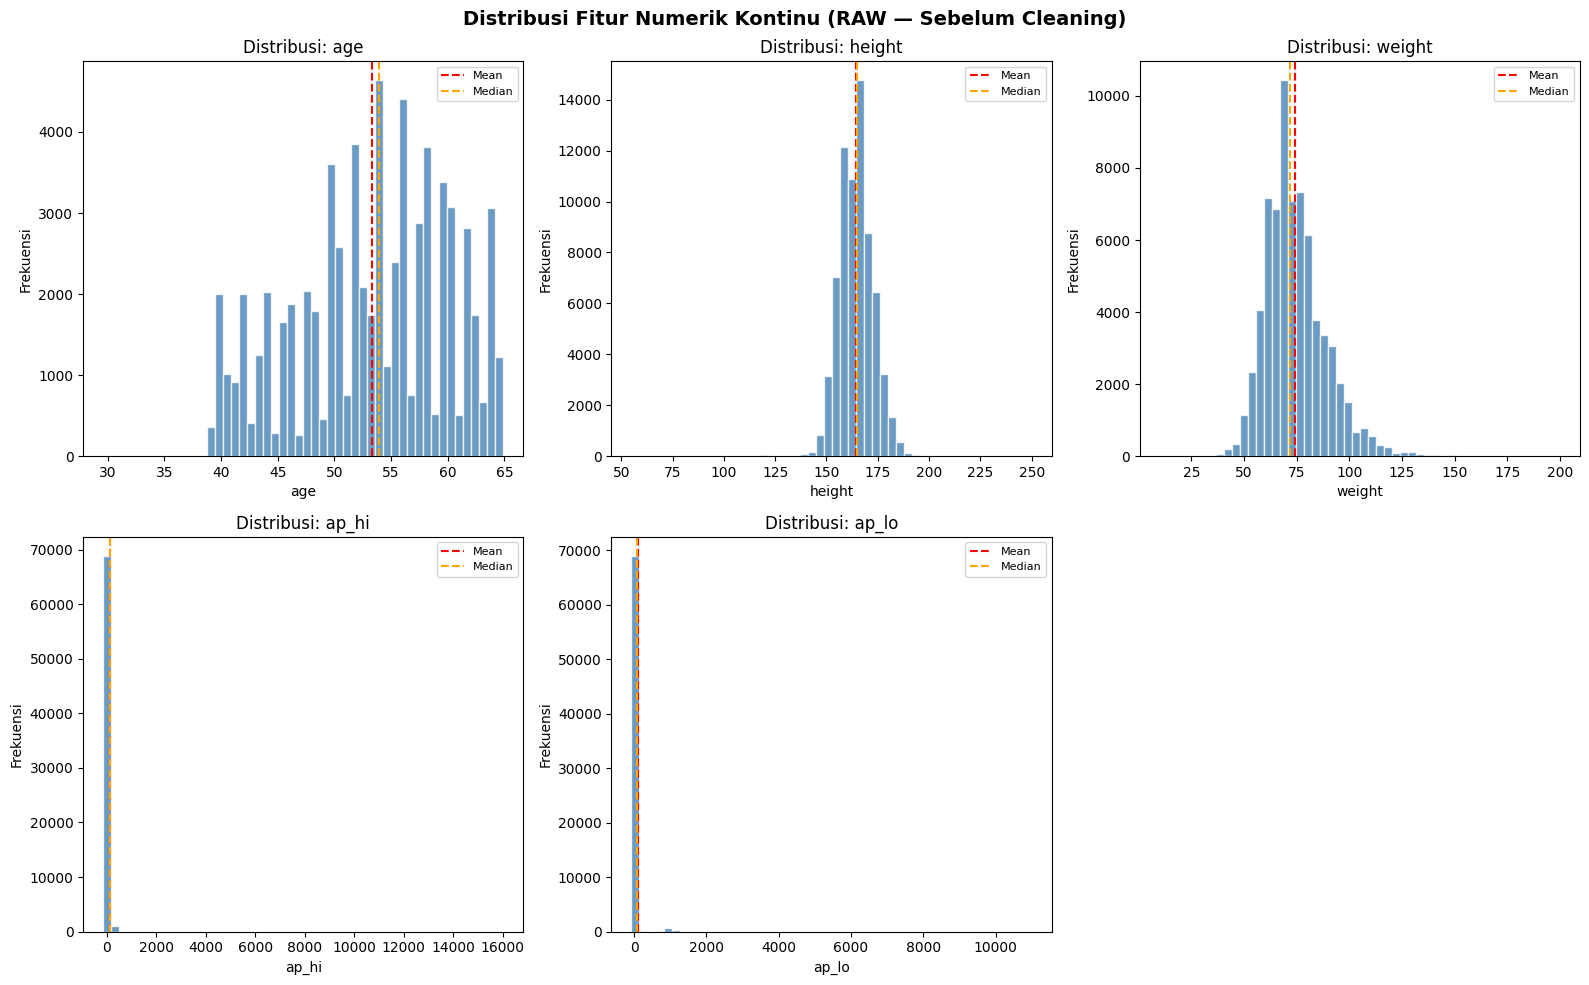

In [ ]:
continuous_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi: {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', label='Median')
    axes[i].legend(fontsize=8)
axes[5].axis('off')
plt.suptitle('Distribusi Fitur Numerik Kontinu (RAW — Sebelum Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_raw.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 6: Visualisasi distribusi fitur kategorikal**

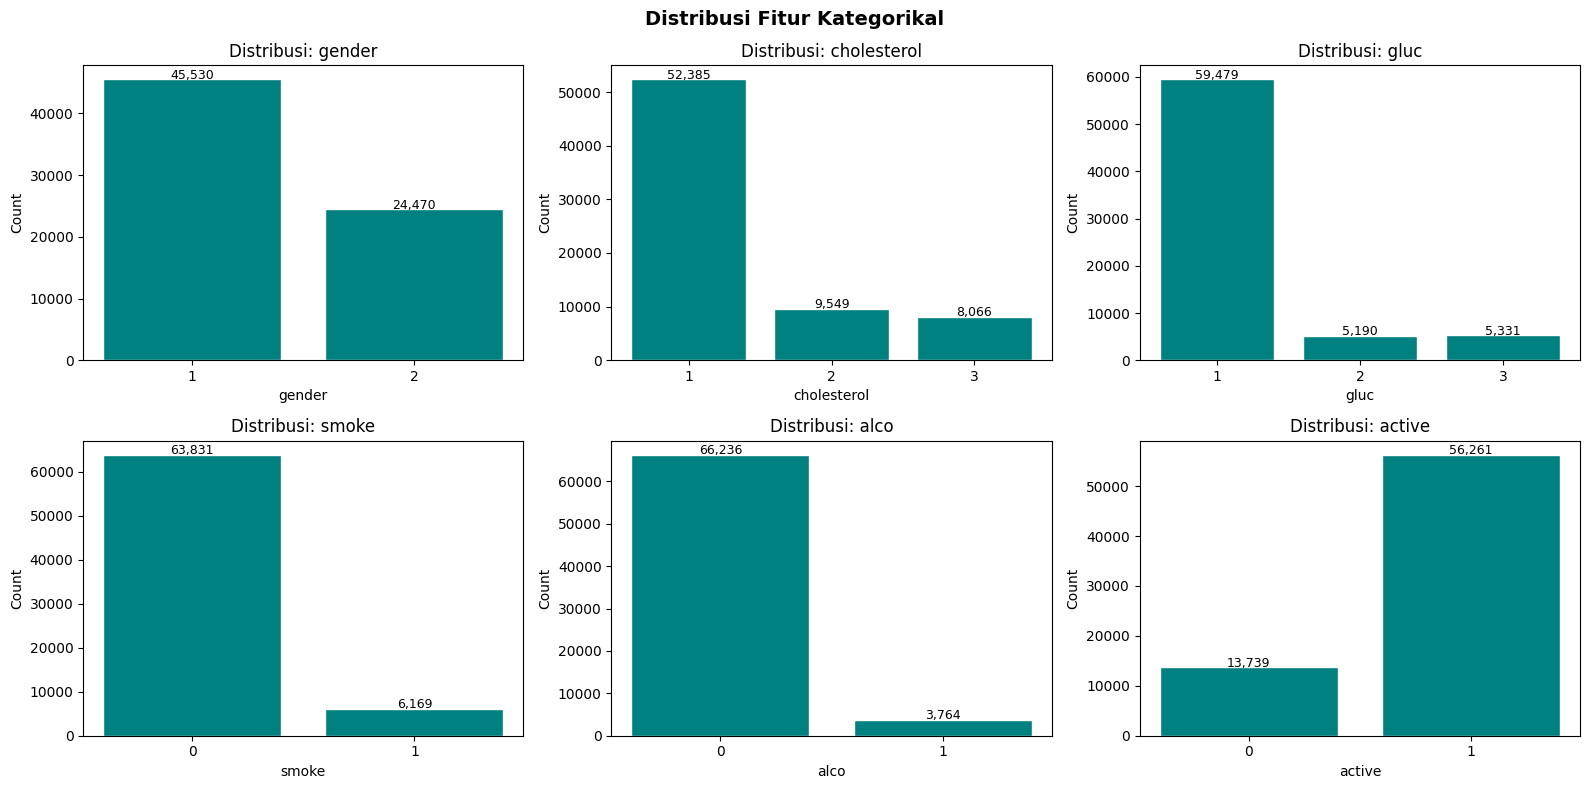

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    val_counts = df[col].value_counts().sort_index()
    axes[i].bar(val_counts.index.astype(str), val_counts.values, color='teal', edgecolor='white')
    axes[i].set_title(f'Distribusi: {col}', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(val_counts.values):
        axes[i].text(j, v + 100, f'{v:,}', ha='center', fontsize=9)
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_cat.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 7: Outlier report menggunakan IQR**

In [ ]:
print(f"\n{'='*60}")
print(f"OUTLIER REPORT (IQR Method)")
print(f"{'='*60}")

outlier_report = {}
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outlier / len(df) * 100
    outlier_report[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                           'lower_bound': lower, 'upper_bound': upper,
                           'n_outliers': n_outlier, 'pct': pct}
    print(f"\n  {col}:")
    print(f"    IQR range : [{lower:.2f}, {upper:.2f}]")
    print(f"    Data range: [{df[col].min():.2f}, {df[col].max():.2f}]")
    print(f"    Outliers  : {n_outlier:,} ({pct:.2f}%)")


OUTLIER REPORT (IQR Method)

  age:
    IQR range : [33.40, 73.40]
    Data range: [29.60, 64.90]
    Outliers  : 4 (0.01%)

  height:
    IQR range : [142.50, 186.50]
    Data range: [55.00, 250.00]
    Outliers  : 519 (0.74%)

  weight:
    IQR range : [39.50, 107.50]
    Data range: [10.00, 200.00]
    Outliers  : 1,819 (2.60%)

  ap_hi:
    IQR range : [90.00, 170.00]
    Data range: [-150.00, 16020.00]
    Outliers  : 1,435 (2.05%)

  ap_lo:
    IQR range : [65.00, 105.00]
    Data range: [-70.00, 11000.00]
    Outliers  : 4,632 (6.62%)


**Sel 8: Boxplot fitur kontinu (sebelum cleaning)**

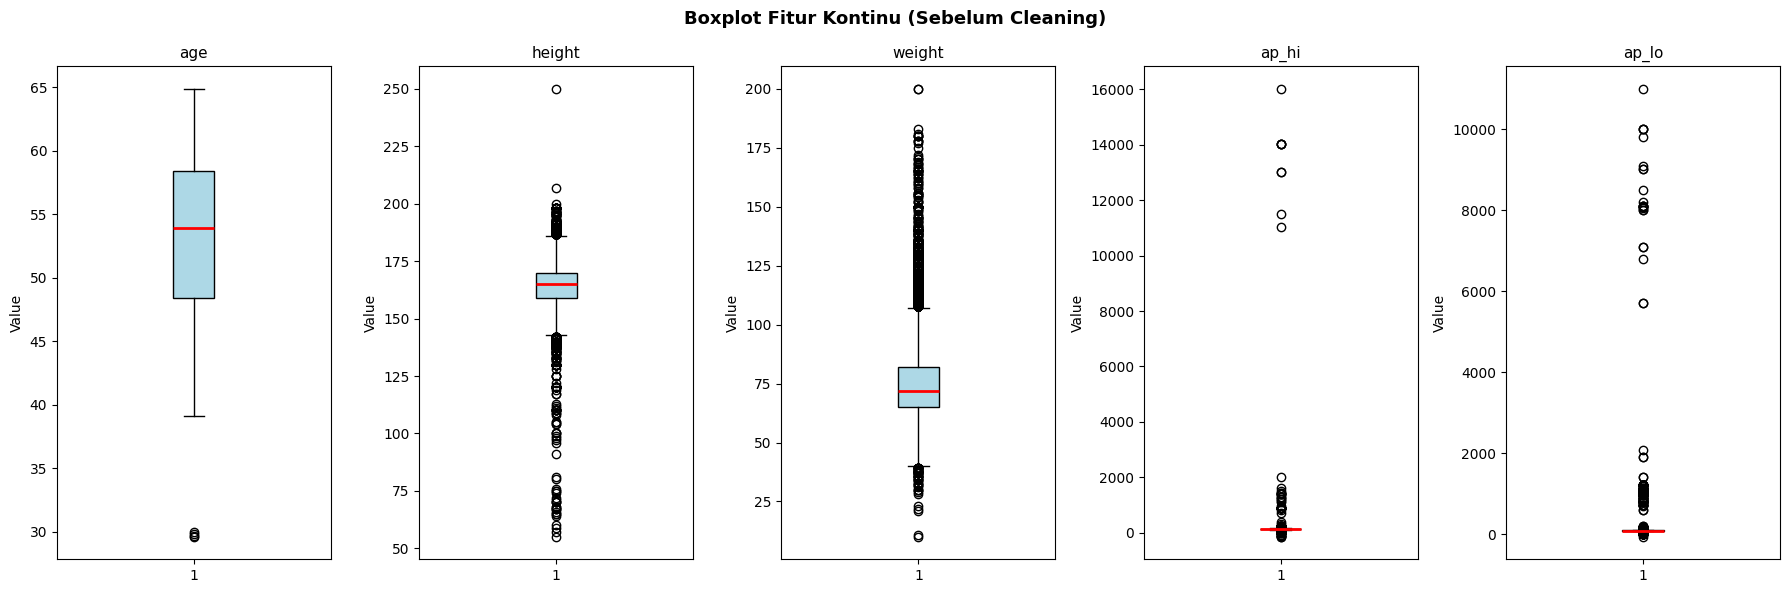

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')
plt.suptitle('Boxplot Fitur Kontinu (Sebelum Cleaning)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_raw.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 9: Medical validity check (filter berdasarkan batasan medis)**

In [ ]:
print(f"\n{'='*60}")
print(f"MEDICAL VALIDITY CHECK")
print(f"{'='*60}")

invalid_aphi  = ((df['ap_hi'] < 60) | (df['ap_hi'] > 250)).sum()
invalid_aplo  = ((df['ap_lo'] < 40) | (df['ap_lo'] > 200)).sum()
invalid_aplo_neg = (df['ap_lo'] < 0).sum()
invalid_aphi_neg = (df['ap_hi'] < 0).sum()
invalid_height = ((df['height'] < 100) | (df['height'] > 220)).sum()
invalid_weight = ((df['weight'] < 30) | (df['weight'] > 180)).sum()

print(f"  ap_hi  < 60 atau > 250 mmHg : {invalid_aphi:,} baris")
print(f"  ap_lo  < 40 atau > 200 mmHg : {invalid_aplo:,} baris")
print(f"  ap_lo  negatif              : {invalid_aplo_neg:,} baris")
print(f"  ap_hi  negatif              : {invalid_aphi_neg:,} baris")
print(f"  height < 100 atau > 220 cm  : {invalid_height:,} baris")
print(f"  weight < 30  atau > 180 kg  : {invalid_weight:,} baris")

total_invalid = df[
    (df['ap_hi'] < 60) | (df['ap_hi'] > 250) |
    (df['ap_lo'] < 40) | (df['ap_lo'] > 200) |
    (df['ap_lo'] < 0)  | (df['ap_hi'] < 0)   |
    (df['height'] < 100) | (df['height'] > 220) |
    (df['weight'] < 30)  | (df['weight'] > 180)
].shape[0]

print(f"\nTotal baris dengan nilai tidak valid medis: {total_invalid:,}")
print(f"Akan tersisa setelah cleaning            : {len(df) - total_invalid:,} baris")


MEDICAL VALIDITY CHECK
  ap_hi  < 60 atau > 250 mmHg : 228 baris
  ap_lo  < 40 atau > 200 mmHg : 1,012 baris
  ap_lo  negatif              : 1 baris
  ap_hi  negatif              : 7 baris
  height < 100 atau > 220 cm  : 30 baris
  weight < 30  atau > 180 kg  : 11 baris

Total baris dengan nilai tidak valid medis: 1,261
Akan tersisa setelah cleaning            : 68,739 baris


**Sel 10: Cleaning data (filter outlier medis)**

In [ ]:
df_clean = df.copy()
n_before = len(df_clean)

mask_valid = (
    (df_clean['ap_hi']  >= 60)  & (df_clean['ap_hi']  <= 250) &
    (df_clean['ap_lo']  >= 40)  & (df_clean['ap_lo']  <= 200) &
    (df_clean['height'] >= 100) & (df_clean['height'] <= 220) &
    (df_clean['weight'] >= 30)  & (df_clean['weight'] <= 180)
)

df_clean = df_clean[mask_valid].reset_index(drop=True)
n_after  = len(df_clean)
n_removed = n_before - n_after

**Sel 11: Laporan cleaning & distribusi target setelah cleaning**

In [ ]:
print(f"{'='*55}")
print(f"CLEANING REPORT")
print(f"{'='*55}")
print(f"  Baris sebelum cleaning : {n_before:,}")
print(f"  Baris dihapus          : {n_removed:,} ({n_removed/n_before*100:.2f}%)")
print(f"  Baris setelah cleaning : {n_after:,}")

print(f"\nTarget Distribution Setelah Cleaning")
print(df_clean['cardio'].value_counts())
print(df_clean['cardio'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

CLEANING REPORT
  Baris sebelum cleaning : 70,000
  Baris dihapus          : 1,261 (1.80%)
  Baris setelah cleaning : 68,739

Target Distribution Setelah Cleaning
cardio
0    34719
1    34020
Name: count, dtype: int64
cardio
0    50.51%
1    49.49%
Name: proportion, dtype: object


**Sel 12: Validasi range fitur setelah cleaning**

In [ ]:
print(f"\nValidasi Range Fitur Setelah Cleaning")
check_cols = ['ap_hi', 'ap_lo', 'height', 'weight', 'age']
for col in check_cols:
    print(f"  {col:8s}: [{df_clean[col].min():.1f}, {df_clean[col].max():.1f}]  "
          f"mean={df_clean[col].mean():.1f}  std={df_clean[col].std():.1f}")


Validasi Range Fitur Setelah Cleaning
  ap_hi   : [60.0, 240.0]  mean=126.6  std=16.8
  ap_lo   : [40.0, 190.0]  mean=81.4  std=9.7
  height  : [100.0, 207.0]  mean=164.4  std=8.0
  weight  : [30.0, 180.0]  mean=74.1  std=14.3
  age     : [29.6, 64.9]  mean=53.3  std=6.8


**Sel 13: Boxplot setelah cleaning**

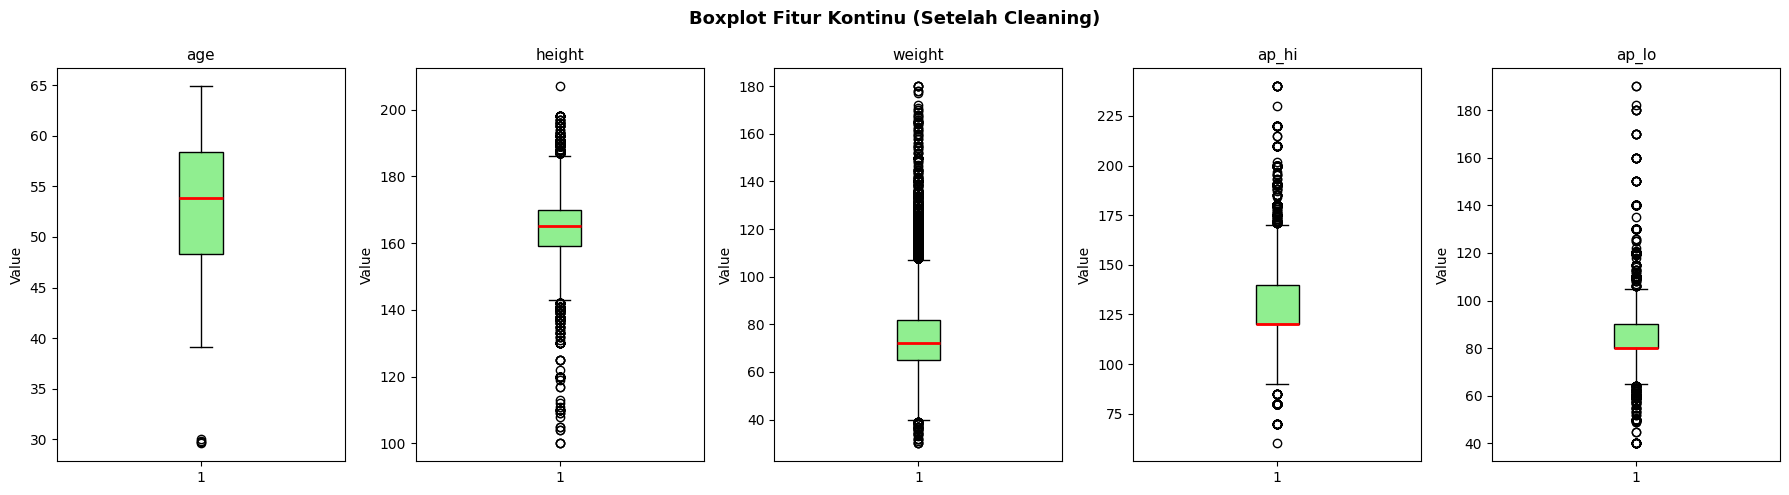

In [ ]:
continuous_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')
plt.suptitle('Boxplot Fitur Kontinu (Setelah Cleaning)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_clean.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 14: Histogram setelah cleaning**

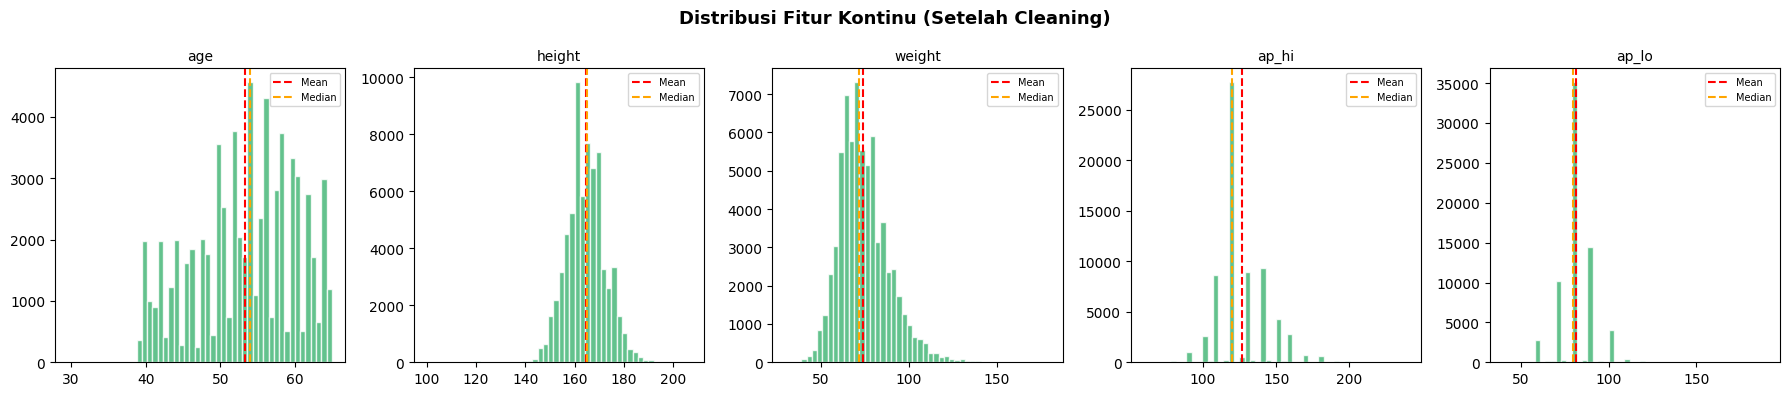

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(continuous_cols):
    axes[i].hist(df_clean[col], bins=50, color='mediumseagreen', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].axvline(df_clean[col].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    axes[i].axvline(df_clean[col].median(), color='orange', linestyle='--', linewidth=1.5, label='Median')
    axes[i].legend(fontsize=7)
plt.suptitle('Distribusi Fitur Kontinu (Setelah Cleaning)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_clean.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 15: Validasi df_clean sebelum Feature Engineering**

In [ ]:
# Validasi bahwa df_clean sudah bersih dan siap untuk feature engineering.
# BMI tidak dibuat di sini; pembuatan fitur baru dilakukan secara terpusat
# pada tahap Feature Creation (Sel 17) agar alur pipeline tetap rapi.

print("Validasi df_clean sebelum Feature Engineering")
print(f"  Shape   : {df_clean.shape}")
print(f"  Kolom   : {list(df_clean.columns)}")
print(f"  Missing : {df_clean.isnull().sum().sum()} nilai")
print(f"  Range height: [{df_clean['height'].min()}, {df_clean['height'].max()}] cm")
print(f"  Range weight: [{df_clean['weight'].min()}, {df_clean['weight'].max()}] kg")
print(f"  Range ap_hi : [{df_clean['ap_hi'].min()}, {df_clean['ap_hi'].max()}] mmHg")
print(f"  Range ap_lo : [{df_clean['ap_lo'].min()}, {df_clean['ap_lo'].max()}] mmHg")
print("\ndf_clean siap untuk tahap Feature Creation.")


Validasi df_clean sebelum Feature Engineering
  Shape   : (68739, 12)
  Kolom   : ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
  Missing : 0 nilai
  Range height: [100, 207] cm
  Range weight: [30.0, 180.0] kg
  Range ap_hi : [60, 240] mmHg
  Range ap_lo : [40, 190] mmHg

df_clean siap untuk tahap Feature Creation.


**Sel 16: Final df_clean siap digunakan**

In [ ]:
print(f"\ndf_clean siap. Shape final: {df_clean.shape}")
print(f"Kolom: {list(df_clean.columns)}")


df_clean siap. Shape final: (68739, 12)
Kolom: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


**Sel 17: Feature Creation**

In [ ]:
from scipy import stats

df_fe = df_clean.copy()

print("="*55)
print("BAGIAN A: FEATURE CREATION")
print("="*55)

df_fe['bmi'] = df_fe['weight'] / ((df_fe['height'] / 100) ** 2)
df_fe['pulse_pressure'] = df_fe['ap_hi'] - df_fe['ap_lo']
df_fe['map'] = df_fe['ap_lo'] + (df_fe['pulse_pressure'] / 3)
df_fe['age_group'] = pd.cut(df_fe['age'],
                             bins=[0, 40, 50, 60, 100],
                             labels=[0, 1, 2, 3]).astype(int)
df_fe['bmi_category'] = pd.cut(df_fe['bmi'],
                                bins=[0, 18.5, 25, 30, 1000],
                                labels=[0, 1, 2, 3]).astype(int)

new_features = ['bmi', 'pulse_pressure', 'map', 'age_group', 'bmi_category']
print(f"\n  Fitur baru yang ditambahkan: {new_features}")
print(f"  Shape setelah feature creation: {df_fe.shape}")

print(f"\nStatistik Fitur Baru")
print(df_fe[new_features].describe().round(2))

BAGIAN A: FEATURE CREATION

  Fitur baru yang ditambahkan: ['bmi', 'pulse_pressure', 'map', 'age_group', 'bmi_category']
  Shape setelah feature creation: (68739, 17)

Statistik Fitur Baru
             bmi  pulse_pressure        map  age_group  bmi_category
count 68739.0000      68739.0000 68739.0000 68739.0000    68739.0000
mean     27.4700         45.2300    96.4600     1.8300        1.8700
std       5.3500         12.1800    11.1000     0.7400        0.8100
min      10.7300        -90.0000    46.6700     0.0000        0.0000
25%      23.8800         40.0000    93.3300     1.0000        1.0000
50%      26.3500         40.0000    93.3300     2.0000        2.0000
75%      30.1200         50.0000   103.3300     2.0000        3.0000
max     152.5500        140.0000   186.6700     3.0000        3.0000


**Sel 18: Heatmap Korelasi**


BAGIAN B: HEATMAP KORELASI

Korelasi Setiap Fitur dengan Target 'cardio'
  ap_hi          : +0.4251  █████████████████
  map            : +0.4088  ████████████████
  ap_lo          : +0.3350  █████████████
  pulse_pressure : +0.3191  ████████████
  age            : +0.2396  █████████
  cholesterol    : +0.2215  ████████
  age_group      : +0.2164  ████████
  bmi            : +0.1863  ███████
  bmi_category   : +0.1834  ███████
  weight         : +0.1800  ███████
  gluc           : +0.0900  ███
  gender         : +0.0073  
  alco           : -0.0082  
  height         : -0.0121  
  smoke          : -0.0163  
  active         : -0.0374  █


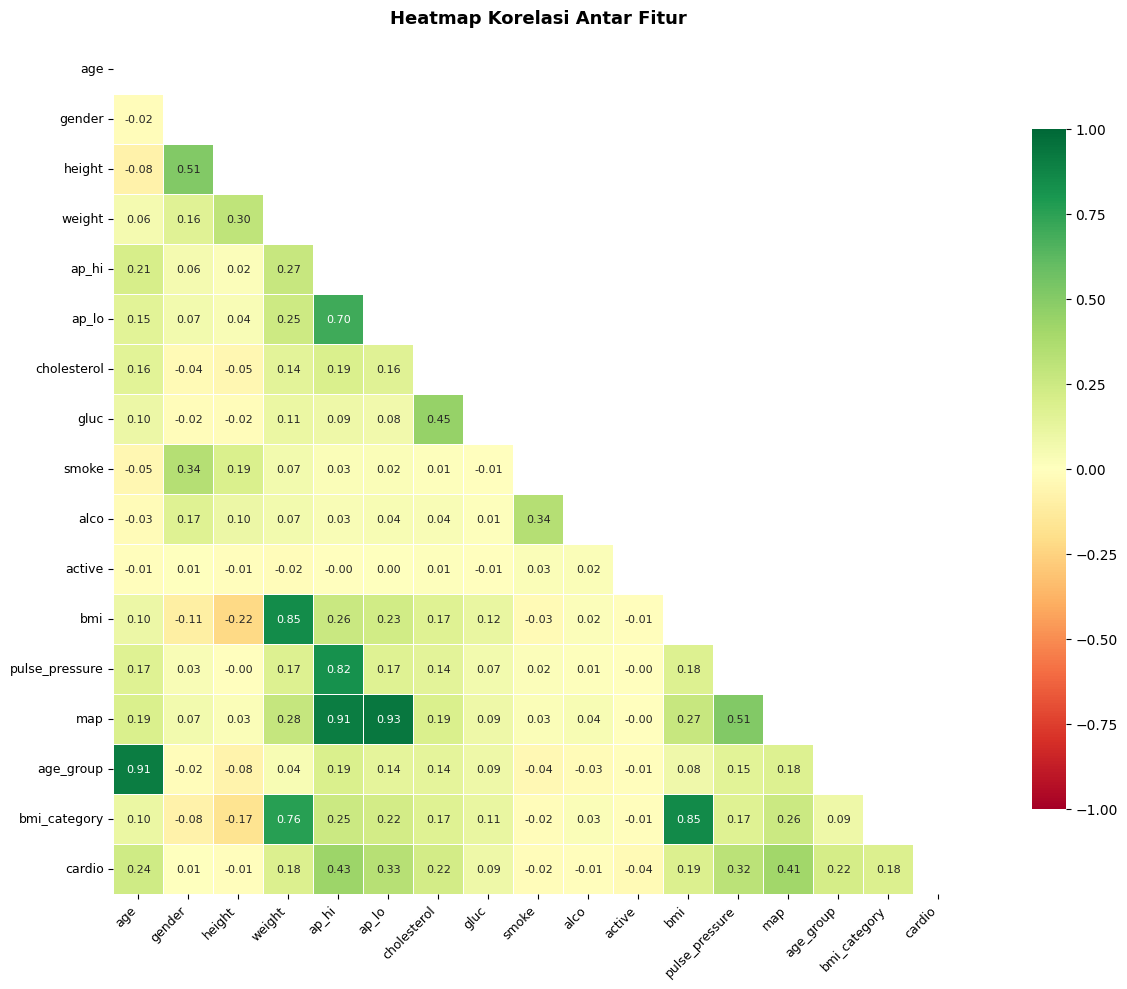

In [ ]:
print(f"\n{'='*55}")
print(f"BAGIAN B: HEATMAP KORELASI")
print(f"{'='*55}")

corr_matrix = df_fe.drop(columns=['cardio']).join(df_fe['cardio']).corr()
corr_with_target = corr_matrix['cardio'].drop('cardio').sort_values(ascending=False)

print(f"\nKorelasi Setiap Fitur dengan Target 'cardio'")
for feat, val in corr_with_target.items():
    bar = '█' * int(abs(val) * 40)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:15s}: {sign}{abs(val):.4f}  {bar}")

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('heatmap_corr.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 19: Identifikasi korelasi tinggi dan rendah (Feature Selection)**

In [ ]:
print(f"\n{'='*55}")
print(f"BAGIAN C: FEATURE SELECTION")
print(f"{'='*55}")

feat_cols = [c for c in df_fe.columns if c != 'cardio']
corr_feat  = df_fe[feat_cols].corr().abs()
upper_tri  = corr_feat.where(np.triu(np.ones(corr_feat.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if val > 0.85:
            high_corr_pairs.append((idx, col, val))

print(f"\n  Pasangan fitur dengan korelasi > 0.85:")
if high_corr_pairs:
    for a, b, v in high_corr_pairs:
        print(f"    {a} ↔ {b}: {v:.4f}")
else:
    print(f"    Tidak ada pasangan dengan korelasi > 0.85")

print(f"\n  Fitur dengan |korelasi terhadap target| < 0.02:")
low_corr_feats = corr_with_target[abs(corr_with_target) < 0.02]
if len(low_corr_feats) > 0:
    for f, v in low_corr_feats.items():
        print(f"    {f}: {v:.4f}")
else:
    print(f"    Tidak ada fitur dengan korelasi < 0.02")


BAGIAN C: FEATURE SELECTION

  Pasangan fitur dengan korelasi > 0.85:
    weight ↔ bmi: 0.8509
    ap_hi ↔ map: 0.9092
    ap_lo ↔ map: 0.9327
    age ↔ age_group: 0.9131
    bmi ↔ bmi_category: 0.8516

  Fitur dengan |korelasi terhadap target| < 0.02:
    gender: 0.0073
    alco: -0.0082
    height: -0.0121
    smoke: -0.0163


**Sel 20: Normalisasi / Standardisasi**

Standardisasi dilakukan menggunakan `StandardScaler` pada fitur kontinu.
Untuk menghindari data leakage, scaler di-fit hanya pada data training (split 80:20),
kemudian parameter hasil fit tersebut digunakan untuk mentransformasi seluruh dataset.
Pendekatan ini memastikan statistik dari data test tidak memengaruhi proses scaling.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("=" * 55)
print("BAGIAN D: NORMALISASI / STANDARDISASI")
print("=" * 55)

scale_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo',
              'bmi', 'pulse_pressure', 'map']
no_scale_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco',
                 'active', 'age_group', 'bmi_category']

print(f"\n  Kolom yang di-StandardScaler : {scale_cols}")
print(f"  Kolom yang tidak di-scale    : {no_scale_cols}")

# Pisahkan fitur dan target sebelum scaling
X_raw_all = df_fe.drop(columns=['cardio'])
y_all     = df_fe['cardio']

# Split data terlebih dahulu menggunakan rasio 80:20 untuk mendapatkan
# statistik training yang akan digunakan sebagai acuan scaling.
# Dengan cara ini, scaler hanya mempelajari distribusi dari data training,
# sehingga tidak ada informasi dari data test yang bocor ke proses training.
X_tr_ref, X_te_ref, _, _ = train_test_split(
    X_raw_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

print(f"\nStats SEBELUM Scaling (dari distribusi asli)")
for col in ['age', 'ap_hi', 'bmi']:
    print(f"  {col:15s}: mean={df_fe[col].mean():.2f}, std={df_fe[col].std():.2f}, "
          f"min={df_fe[col].min():.2f}, max={df_fe[col].max():.2f}")

# Fit scaler HANYA pada data training (80%) — tidak pada full dataset
scaler = StandardScaler()
scaler.fit(X_tr_ref[scale_cols])

# Terapkan transformasi ke seluruh dataset menggunakan parameter dari train
df_scaled = df_fe.copy()
df_scaled[scale_cols] = scaler.transform(df_fe[scale_cols])

print(f"\nStats SESUDAH StandardScaler (parameter dari train set 80%)")
for col in ['age', 'ap_hi', 'bmi']:
    print(f"  {col:15s}: mean={df_scaled[col].mean():.4f}, std={df_scaled[col].std():.4f}, "
          f"min={df_scaled[col].min():.2f}, max={df_scaled[col].max():.2f}")

print("\nScaling selesai. Parameter scaler berasal dari training set, bukan full dataset.")


BAGIAN D: NORMALISASI / STANDARDISASI

  Kolom yang di-StandardScaler : ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure', 'map']
  Kolom yang tidak di-scale    : ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_group', 'bmi_category']

Stats SEBELUM Scaling (dari distribusi asli)
  age            : mean=53.29, std=6.76, min=29.60, max=64.90
  ap_hi          : mean=126.62, std=16.76, min=60.00, max=240.00
  bmi            : mean=27.47, std=5.35, min=10.73, max=152.55

Stats SESUDAH StandardScaler (parameter dari train set 80%)
  age            : mean=-0.0038, std=1.0011, min=-3.51, max=1.72
  ap_hi          : mean=-0.0032, std=0.9990, min=-3.97, max=6.75
  bmi            : mean=-0.0002, std=1.0060, min=-3.15, max=23.53

Scaling selesai. Parameter scaler berasal dari training set, bukan full dataset.


**Sel 21: Final Feature Set**

In [ ]:
print(f"\n{'='*55}")
print(f"BAGIAN E: FINAL FEATURE SET")
print(f"{'='*55}")

X_all = df_scaled.drop(columns=['cardio'])
y     = df_scaled['cardio']

print(f"\n  Total fitur tersedia: {X_all.shape[1]}")
print(f"  Fitur: {list(X_all.columns)}")
print(f"\n  Korelasi terhadap target:")
corr_final = df_fe[list(X_all.columns)].corrwith(df_fe['cardio']).abs().sort_values(ascending=False)
for f, v in corr_final.items():
    print(f"    {f:15s}: {v:.4f}")


BAGIAN E: FINAL FEATURE SET

  Total fitur tersedia: 16
  Fitur: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure', 'map', 'age_group', 'bmi_category']

  Korelasi terhadap target:
    ap_hi          : 0.4251
    map            : 0.4088
    ap_lo          : 0.3350
    pulse_pressure : 0.3191
    age            : 0.2396
    cholesterol    : 0.2215
    age_group      : 0.2164
    bmi            : 0.1863
    bmi_category   : 0.1834
    weight         : 0.1800
    gluc           : 0.0900
    active         : 0.0374
    smoke          : 0.0163
    height         : 0.0121
    alco           : 0.0082
    gender         : 0.0073


**Sel 22: Feature Selection Decision (memilih fitur yang akan di-drop)**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

dropped_redundant = ['map', 'age_group', 'bmi_category', 'weight']

print("=" * 55)
print("FEATURE SELECTION DECISION")
print("=" * 55)
print(f"\n  Drop (redundan, korelasi antar-fitur > 0.85):")
for f in dropped_redundant:
    print(f"    - {f}")
print(f"\n  Pertahankan (bermakna secara domain medis):")
for f in ['gender', 'alco', 'height', 'smoke']:
    corr_val = abs(df_fe[f].corr(df_fe['cardio']))
    print(f"    {f:8s} (|corr dengan target|={corr_val:.4f}) — relevan secara klinis")


FEATURE SELECTION DECISION

  Drop (redundan, korelasi antar-fitur > 0.85):
    - map
    - age_group
    - bmi_category
    - weight

  Pertahankan (bermakna secara domain medis):
    gender   (|corr dengan target|=0.0073) — relevan secara klinis
    alco     (|corr dengan target|=0.0082) — relevan secara klinis
    height   (|corr dengan target|=0.0121) — relevan secara klinis
    smoke    (|corr dengan target|=0.0163) — relevan secara klinis


**Sel 23: Membuat dataset sebelum dan sesudah feature selection**

In [ ]:
X_before = df_scaled.drop(columns=['cardio'])
y        = df_scaled['cardio']
X_final  = df_scaled.drop(columns=['cardio'] + dropped_redundant)

print(f"\n  Fitur SEBELUM selection : {X_before.shape[1]} fitur")
print(f"  Fitur SESUDAH selection : {X_final.shape[1]} fitur")
print(f"\n  Fitur final yang DIPERTAHANKAN:")
for i, f in enumerate(X_final.columns, 1):
    corr_val = abs(df_fe[f].corr(df_fe['cardio']))
    print(f"    {i:2d}. {f:15s} (|corr|={corr_val:.4f})")


  Fitur SEBELUM selection : 16 fitur
  Fitur SESUDAH selection : 12 fitur

  Fitur final yang DIPERTAHANKAN:
     1. age             (|corr|=0.2396)
     2. gender          (|corr|=0.0073)
     3. height          (|corr|=0.0121)
     4. ap_hi           (|corr|=0.4251)
     5. ap_lo           (|corr|=0.3350)
     6. cholesterol     (|corr|=0.2215)
     7. gluc            (|corr|=0.0900)
     8. smoke           (|corr|=0.0163)
     9. alco            (|corr|=0.0082)
    10. active          (|corr|=0.0374)
    11. bmi             (|corr|=0.1863)
    12. pulse_pressure  (|corr|=0.3191)


**Sel 25: Perbandingan performa sebelum vs sesudah (Logistic Regression, CV=5)**

In [ ]:
print(f"\n{'='*55}")
print(f"BEFORE vs AFTER FEATURE SELECTION COMPARISON")
print(f"{'='*55}")
print(f"  Model: Logistic Regression | CV: StratifiedKFold k=5")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

results_comparison = {}
for label, X_eval in [('BEFORE (16 fitur)', X_before),
                       ('AFTER  (12 fitur)', X_final)]:
    auc_scores = cross_val_score(lr, X_eval, y, cv=cv, scoring='roc_auc')
    f1_scores  = cross_val_score(lr, X_eval, y, cv=cv, scoring='f1')
    acc_scores = cross_val_score(lr, X_eval, y, cv=cv, scoring='accuracy')
    results_comparison[label] = {
        'ROC-AUC' : auc_scores,
        'F1'      : f1_scores,
        'Accuracy': acc_scores
    }
    print(f"\n  [{label}]")
    print(f"    ROC-AUC : {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print(f"    F1-Score: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"    Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")


BEFORE vs AFTER FEATURE SELECTION COMPARISON
  Model: Logistic Regression | CV: StratifiedKFold k=5

  [BEFORE (16 fitur)]
    ROC-AUC : 0.7903 ± 0.0031
    F1-Score: 0.7075 ± 0.0019
    Accuracy: 0.7268 ± 0.0018

  [AFTER  (12 fitur)]
    ROC-AUC : 0.7904 ± 0.0030
    F1-Score: 0.7078 ± 0.0021
    Accuracy: 0.7272 ± 0.0021


**Sel 26: Visualisasi perbandingan performa (bar chart)**

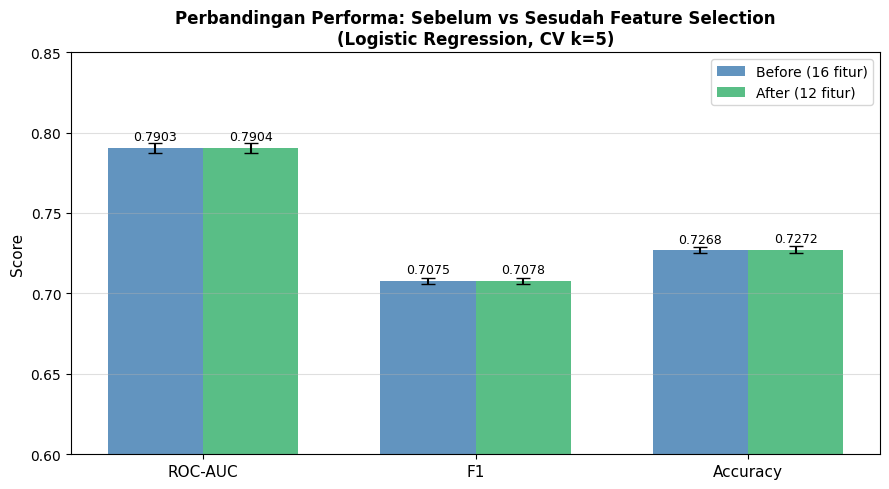

In [ ]:
metrics_list = ['ROC-AUC', 'F1', 'Accuracy']
before_means = [results_comparison['BEFORE (16 fitur)'][m].mean() for m in metrics_list]
after_means  = [results_comparison['AFTER  (12 fitur)'][m].mean() for m in metrics_list]
before_stds  = [results_comparison['BEFORE (16 fitur)'][m].std()  for m in metrics_list]
after_stds   = [results_comparison['AFTER  (12 fitur)'][m].std()  for m in metrics_list]

x = np.arange(len(metrics_list))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - w/2, before_means, w, yerr=before_stds,
               label='Before (16 fitur)', color='steelblue',
               capsize=5, alpha=0.85, error_kw={'elinewidth': 1.5})
bars2 = ax.bar(x + w/2, after_means,  w, yerr=after_stds,
               label='After (12 fitur)',  color='mediumseagreen',
               capsize=5, alpha=0.85, error_kw={'elinewidth': 1.5})

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=9)

ax.set_ylim(0.60, 0.85)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Perbandingan Performa: Sebelum vs Sesudah Feature Selection\n'
             '(Logistic Regression, CV k=5)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('before_after_selection.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 27: Dataset final (X_final, y) setelah feature selection**

In [ ]:
print(f"\n{'='*55}")
print(f"DATASET FINAL")
print(f"{'='*55}")
print(f"  X_final shape : {X_final.shape}")
print(f"  y shape       : {y.shape}")
print(f"  Fitur final   : {list(X_final.columns)}")


DATASET FINAL
  X_final shape : (68739, 12)
  y shape       : (68739,)
  Fitur final   : ['age', 'gender', 'height', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure']


# **Tahap 02: Model Baseline**

Lima model klasifikasi dilatih dan dievaluasi pada dua variasi split data (80:20 dan 70:30) menggunakan Stratified K-Fold Cross-Validation dengan k=5. Model yang diuji adalah Logistic Regression (LR), K-Nearest Neighbors (KNN), Decision Tree (DT), Random Forest (RF), dan Support Vector Machine (SVM). Evaluasi mencakup ROC-AUC, F1-Score, Accuracy, Precision, dan Recall. Random Forest dipilih sebagai model terbaik untuk hyperparameter tuning berdasarkan nilai Recall tertinggi, yang paling relevan untuk kasus skrining medis.

**Sel 28: Import library, definisi model, splits, dan cross-validation**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score)
import time
import warnings
warnings.filterwarnings('ignore')

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'KNN'                : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM (Linear)'       : CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42))
}

splits = {'80:20': 0.20, '70:30': 0.30}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_results = {}

print("="*65)
print("TAHAP 02 — BASELINE MODELING")
print("="*65)
print(f"  Fitur : {list(X_final.columns)}")
print(f"  Shape : {X_final.shape}")

TAHAP 02 — BASELINE MODELING
  Fitur : ['age', 'gender', 'height', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'pulse_pressure']
  Shape : (68739, 12)


**Sel 29: Evaluasi baseline untuk setiap split (80:20 dan 70:30)**

In [ ]:
for split_name, test_size in splits.items():
    print(f"\n{'='*65}")
    print(f"SPLIT {split_name}")
    print(f"{'='*65}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_final, y, test_size=test_size, random_state=42, stratify=y
    )
    print(f"  Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}")

    all_results[split_name] = {}

    for model_name, model in models.items():
        print(f"\n  ── {model_name} ──", end=' ', flush=True)
        t0 = time.time()

        cv_auc = cross_val_score(model, X_train, y_train,
                                 cv=cv, scoring='roc_auc', n_jobs=-1)
        cv_f1  = cross_val_score(model, X_train, y_train,
                                 cv=cv, scoring='f1', n_jobs=-1)
        cv_acc = cross_val_score(model, X_train, y_train,
                                 cv=cv, scoring='accuracy', n_jobs=-1)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        elapsed = time.time() - t0

        all_results[split_name][model_name] = {
            'cv_auc_mean'    : cv_auc.mean(),  'cv_auc_std'  : cv_auc.std(),
            'cv_f1_mean'     : cv_f1.mean(),   'cv_f1_std'   : cv_f1.std(),
            'cv_acc_mean'    : cv_acc.mean(),  'cv_acc_std'  : cv_acc.std(),
            'test_auc'       : roc_auc_score(y_test, y_prob),
            'test_f1'        : f1_score(y_test, y_pred),
            'test_acc'       : accuracy_score(y_test, y_pred),
            'test_precision' : precision_score(y_test, y_pred),
            'test_recall'    : recall_score(y_test, y_pred),
            'time_sec'       : elapsed,
            'y_pred'         : y_pred,
            'y_prob'         : y_prob,
            'y_test'         : y_test
        }

        r = all_results[split_name][model_name]
        print(f"({elapsed:.1f}s)")
        print(f"    CV  → AUC: {r['cv_auc_mean']:.4f}±{r['cv_auc_std']:.4f} | "
              f"F1: {r['cv_f1_mean']:.4f}±{r['cv_f1_std']:.4f} | "
              f"Acc: {r['cv_acc_mean']:.4f}±{r['cv_acc_std']:.4f}")
        print(f"    Test→ AUC: {r['test_auc']:.4f} | F1: {r['test_f1']:.4f} | "
              f"Acc: {r['test_acc']:.4f} | Prec: {r['test_precision']:.4f} | "
              f"Rec: {r['test_recall']:.4f}")


SPLIT 80:20
  Train : 54,991 | Test : 13,748

  ── Logistic Regression ── (5.6s)
    CV  → AUC: 0.7889±0.0039 | F1: 0.7060±0.0044 | Acc: 0.7256±0.0032
    Test→ AUC: 0.7960 | F1: 0.7115 | Acc: 0.7315 | Prec: 0.7599 | Rec: 0.6689

  ── KNN ── (21.8s)
    CV  → AUC: 0.7452±0.0048 | F1: 0.6920±0.0053 | Acc: 0.6987±0.0047
    Test→ AUC: 0.7438 | F1: 0.6861 | Acc: 0.6952 | Prec: 0.6995 | Rec: 0.6733

  ── Decision Tree ── (4.6s)
    CV  → AUC: 0.6336±0.0028 | F1: 0.6280±0.0034 | Acc: 0.6332±0.0031
    Test→ AUC: 0.6339 | F1: 0.6274 | Acc: 0.6343 | Prec: 0.6329 | Rec: 0.6220

  ── Random Forest ── (98.4s)
    CV  → AUC: 0.7701±0.0039 | F1: 0.7016±0.0027 | Acc: 0.7093±0.0023
    Test→ AUC: 0.7727 | F1: 0.7033 | Acc: 0.7118 | Prec: 0.7170 | Rec: 0.6900

  ── SVM (Linear) ── (8.9s)
    CV  → AUC: 0.7888±0.0039 | F1: 0.7067±0.0046 | Acc: 0.7258±0.0035
    Test→ AUC: 0.7958 | F1: 0.7113 | Acc: 0.7307 | Prec: 0.7577 | Rec: 0.6702

SPLIT 70:30
  Train : 48,117 | Test : 20,622

  ── Logistic Regres

**Sel 30: Ringkasan semua model & split**

In [ ]:
print(f"\n{'='*65}")
print(f"RINGKASAN — SEMUA MODEL & SPLIT")
print(f"{'='*65}")

for split_name in splits:
    print(f"\n  [Split {split_name}]")
    print(f"  {'Model':<22} {'CV-AUC':>9} {'CV-F1':>9} {'Test-AUC':>10} "
          f"{'Test-F1':>9} {'Test-Acc':>10} {'Time':>7}")
    print(f"  {'-'*79}")
    for mname, r in all_results[split_name].items():
        print(f"  {mname:<22} "
              f"{r['cv_auc_mean']:>7.4f}   "
              f"{r['cv_f1_mean']:>7.4f}   "
              f"{r['test_auc']:>8.4f}   "
              f"{r['test_f1']:>7.4f}   "
              f"{r['test_acc']:>8.4f}  "
              f"{r['time_sec']:>6.1f}s")


RINGKASAN — SEMUA MODEL & SPLIT

  [Split 80:20]
  Model                     CV-AUC     CV-F1   Test-AUC   Test-F1   Test-Acc    Time
  -------------------------------------------------------------------------------
  Logistic Regression     0.7889    0.7060     0.7960    0.7115     0.7315     5.6s
  KNN                     0.7452    0.6920     0.7438    0.6861     0.6952    21.8s
  Decision Tree           0.6336    0.6280     0.6339    0.6274     0.6343     4.6s
  Random Forest           0.7701    0.7016     0.7727    0.7033     0.7118    98.4s
  SVM (Linear)            0.7888    0.7067     0.7958    0.7113     0.7307     8.9s

  [Split 70:30]
  Model                     CV-AUC     CV-F1   Test-AUC   Test-F1   Test-Acc    Time
  -------------------------------------------------------------------------------
  Logistic Regression     0.7892    0.7067     0.7930    0.7098     0.7289     2.3s
  KNN                     0.7431    0.6896     0.7452    0.6901     0.6984    20.0s
  Decision 

**Sel 31: Visualisasi perbandingan baseline (bar chart AUC & F1 untuk kedua split)**

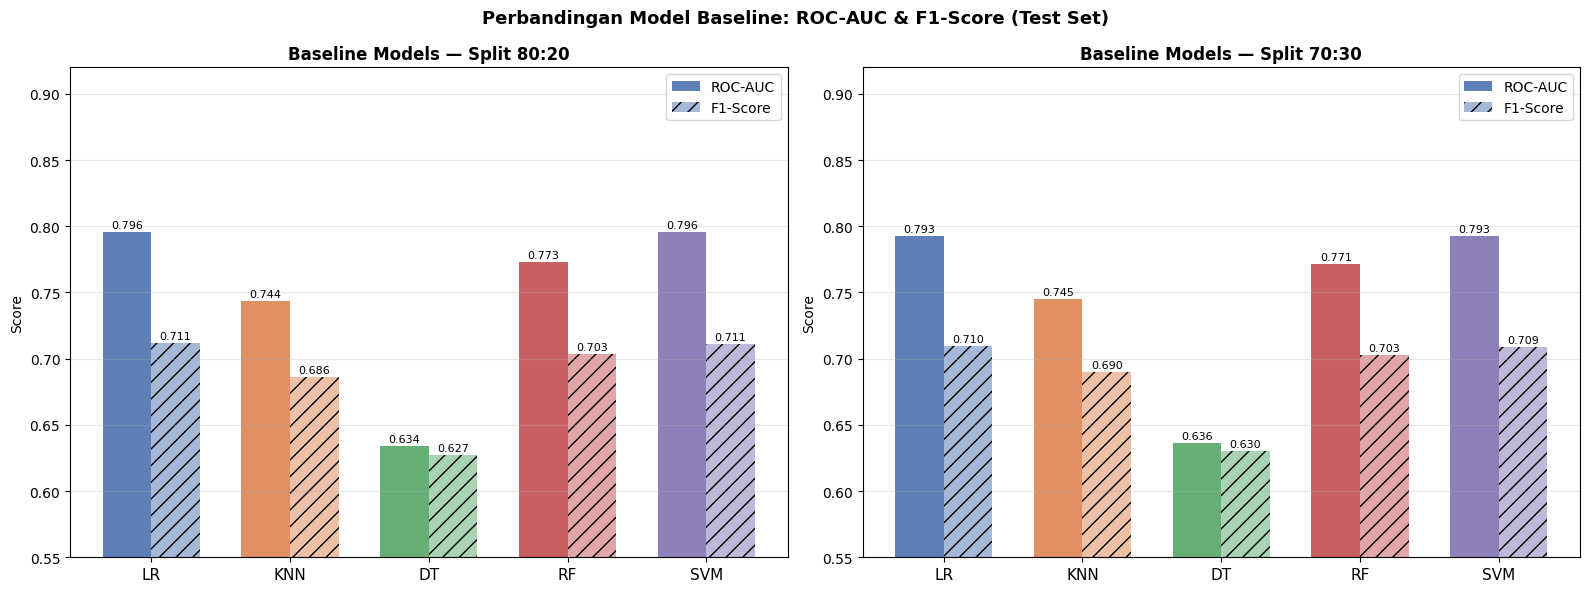

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_names = list(models.keys())
short_names = ['LR', 'KNN', 'DT', 'RF', 'SVM']
colors      = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (split_name, _) in zip(axes, splits.items()):
    auc_vals = [all_results[split_name][m]['test_auc'] for m in model_names]
    f1_vals  = [all_results[split_name][m]['test_f1']  for m in model_names]
    x = np.arange(len(model_names))
    w = 0.35

    bars1 = ax.bar(x - w/2, auc_vals, w, label='ROC-AUC',
                   color=colors, alpha=0.9)
    bars2 = ax.bar(x + w/2, f1_vals,  w, label='F1-Score',
                   color=colors, alpha=0.5, hatch='//')

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

    ax.set_ylim(0.55, 0.92)
    ax.set_title(f'Baseline Models — Split {split_name}',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=11)
    ax.set_ylabel('Score')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Model Baseline: ROC-AUC & F1-Score (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 32: Confusion Matrix untuk semua model (split 80:20 dan 70:30)**

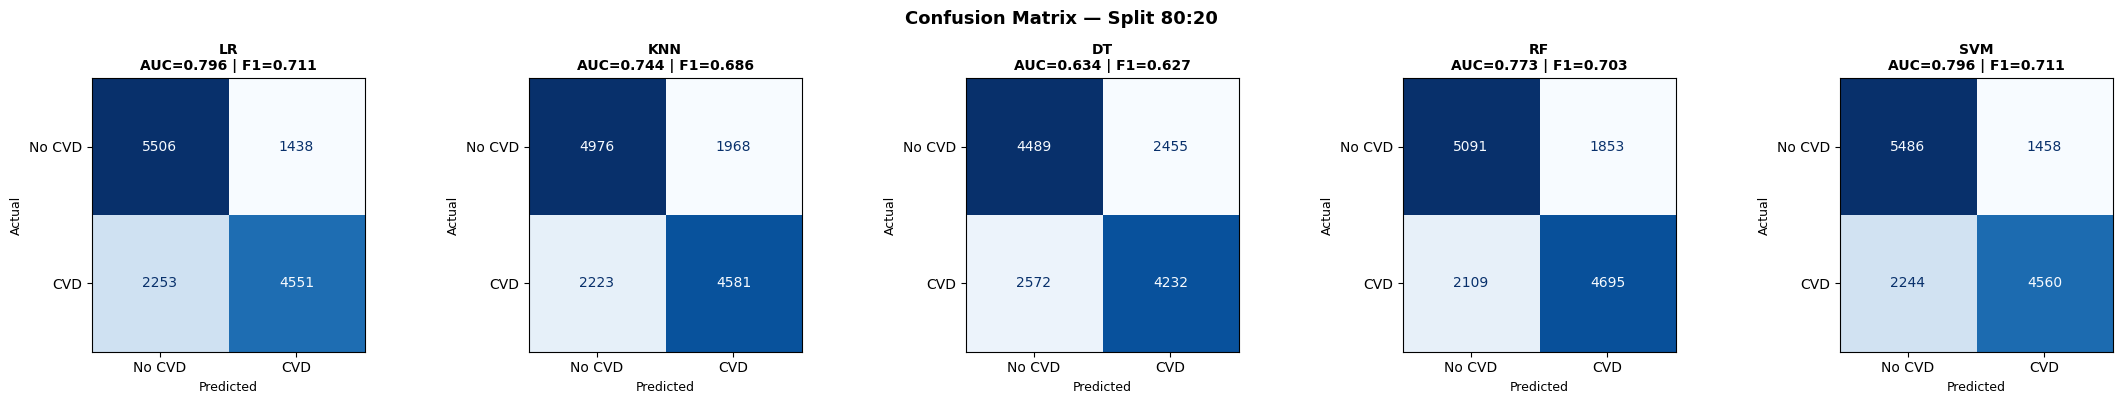

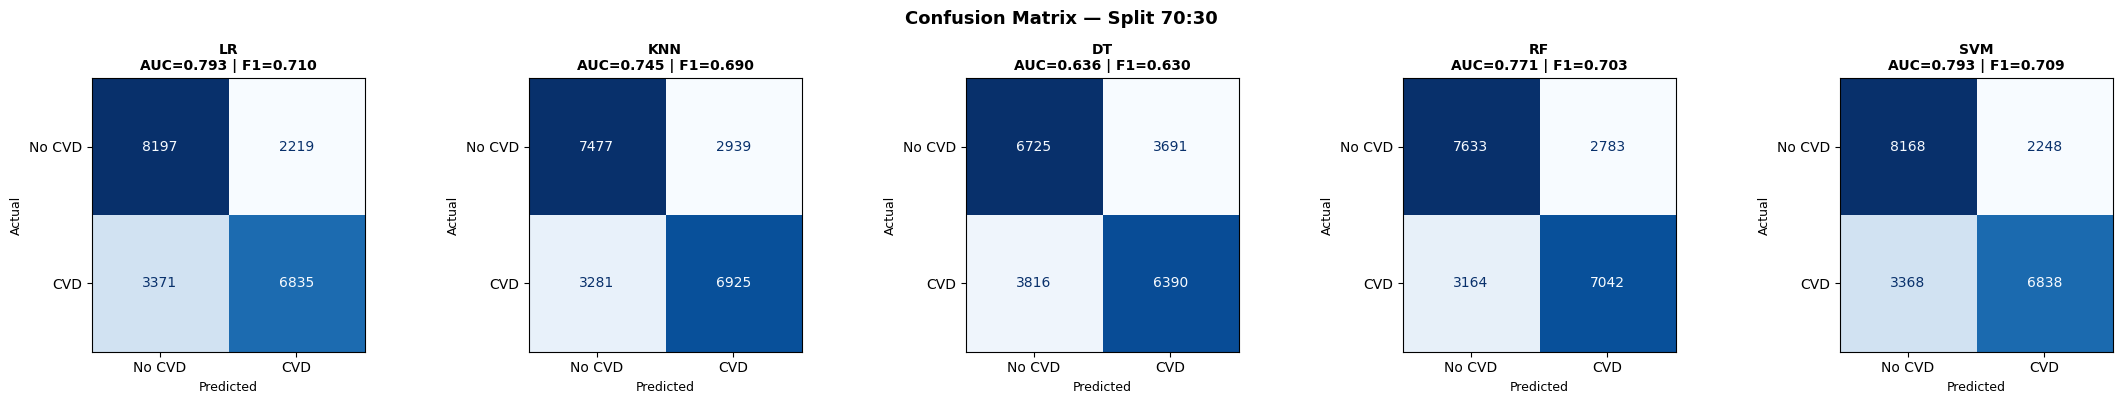

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

model_names = list(models.keys())
short_names = ['LR', 'KNN', 'DT', 'RF', 'SVM']

for split_name in ['80:20', '70:30']:
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(f'Confusion Matrix — Split {split_name}',
                 fontsize=13, fontweight='bold')

    for ax, mname, sname in zip(axes, model_names, short_names):
        r = all_results[split_name][mname]
        cm = confusion_matrix(r['y_test'], r['y_pred'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['No CVD', 'CVD'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        auc_val = r['test_auc']
        f1_val  = r['test_f1']
        ax.set_title(f'{sname}\nAUC={auc_val:.3f} | F1={f1_val:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{split_name.replace(":", "-")}.png',
                dpi=100, bbox_inches='tight')
    plt.show()

**Sel 33: ROC Curve untuk kedua split (perbandingan semua model)**

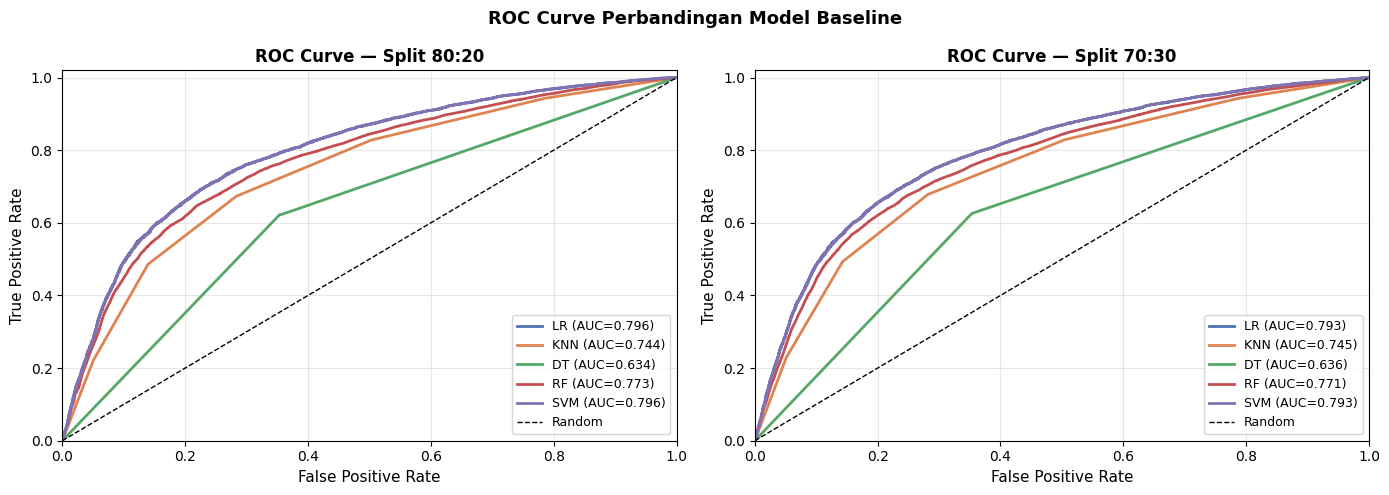

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_roc = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

for ax, split_name in zip(axes, ['80:20', '70:30']):
    for (mname, sname, color) in zip(model_names, short_names, colors_roc):
        r = all_results[split_name][mname]
        fpr, tpr, _ = roc_curve(r['y_test'], r['y_prob'])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{sname} (AUC={roc_auc:.3f})')

    ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'ROC Curve — Split {split_name}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curve Perbandingan Model Baseline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curve_baseline.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 34: Tabel metrik Evaluasi (Split 80:20 dan 70:30)**

In [ ]:
print("="*65)
print("METRIK LENGKAP Split 80:20")
print("="*65)
print(f"\n{'Model':<22} {'AUC':>7} {'F1':>7} {'Acc':>7} {'Prec':>7} {'Rec':>7}")
print("-"*58)
for mname, sname in zip(model_names, short_names):
    r = all_results['80:20'][mname]
    print(f"{mname:<22} {r['test_auc']:>7.4f} {r['test_f1']:>7.4f} "
          f"{r['test_acc']:>7.4f} {r['test_precision']:>7.4f} {r['test_recall']:>7.4f}")

print(f"\n{'Model':<22} {'AUC':>7} {'F1':>7} {'Acc':>7} {'Prec':>7} {'Rec':>7}")
print("Split 70:30")
print("-"*58)
for mname, sname in zip(model_names, short_names):
    r = all_results['70:30'][mname]
    print(f"{mname:<22} {r['test_auc']:>7.4f} {r['test_f1']:>7.4f} "
          f"{r['test_acc']:>7.4f} {r['test_precision']:>7.4f} {r['test_recall']:>7.4f}")

METRIK LENGKAP Split 80:20

Model                      AUC      F1     Acc    Prec     Rec
----------------------------------------------------------
Logistic Regression     0.7960  0.7115  0.7315  0.7599  0.6689
KNN                     0.7438  0.6861  0.6952  0.6995  0.6733
Decision Tree           0.6339  0.6274  0.6343  0.6329  0.6220
Random Forest           0.7727  0.7033  0.7118  0.7170  0.6900
SVM (Linear)            0.7958  0.7113  0.7307  0.7577  0.6702

Model                      AUC      F1     Acc    Prec     Rec
Split 70:30
----------------------------------------------------------
Logistic Regression     0.7930  0.7098  0.7289  0.7549  0.6697
KNN                     0.7452  0.6901  0.6984  0.7020  0.6785
Decision Tree           0.6362  0.6300  0.6360  0.6339  0.6261
Random Forest           0.7712  0.7031  0.7116  0.7167  0.6900
SVM (Linear)            0.7928  0.7089  0.7277  0.7526  0.6700


**Sel 35: Pemilihan Model Terbaik untuk Tuning**

In [ ]:
if 'all_results' in dir():
    best_model_8020 = max(all_results['80:20'].items(),
                          key=lambda x: x[1]['test_recall'])
    print(f"Split 80:20 - Model dengan recall tertinggi: {best_model_8020[0]}")
    print(f"   Recall: {best_model_8020[1]['test_recall']:.4f}, F1: {best_model_8020[1]['test_f1']:.4f}")

    best_model_7030 = max(all_results['70:30'].items(),
                          key=lambda x: x[1]['test_recall'])
    print(f"\nSplit 70:30 - Model dengan recall tertinggi: {best_model_7030[0]}")
    print(f"   Recall: {best_model_7030[1]['test_recall']:.4f}, F1: {best_model_7030[1]['test_f1']:.4f}")

    models_recall = {}
    for model in all_results['80:20'].keys():
        recall_avg = (all_results['80:20'][model]['test_recall'] +
                      all_results['70:30'][model]['test_recall']) / 2
        models_recall[model] = recall_avg

    best_model = max(models_recall, key=models_recall.get)
    print(f"\n=== MODEL TERBAIK UNTUK TUNING ===")
    print(f"Model: {best_model}")
    print(f"Rata-rata Recall: {models_recall[best_model]:.4f}")
    print(f"Alasan: Recall tertinggi penting untuk mendeteksi pasien berisiko (minimalkan False Negative).")

else:
    print("Menggunakan data ringkasan dari baseline:")
    data_8020 = {
        'Logistic Regression': {'recall': 0.6689, 'f1': 0.7115},
        'KNN': {'recall': 0.6737, 'f1': 0.6863},
        'Decision Tree': {'recall': 0.6229, 'f1': 0.6278},
        'Random Forest': {'recall': 0.6905, 'f1': 0.7036},
        'SVM (Linear)': {'recall': 0.6702, 'f1': 0.7113}
    }
    data_7030 = {
        'Logistic Regression': {'recall': 0.6697, 'f1': 0.7098},
        'KNN': {'recall': 0.6789, 'f1': 0.6904},
        'Decision Tree': {'recall': 0.6262, 'f1': 0.6298},
        'Random Forest': {'recall': 0.6904, 'f1': 0.7036},
        'SVM (Linear)': {'recall': 0.6700, 'f1': 0.7089}
    }

    best_recall_8020 = max(data_8020.items(), key=lambda x: x[1]['recall'])
    best_recall_7030 = max(data_7030.items(), key=lambda x: x[1]['recall'])
    print(f"Split 80:20 - Model recall tertinggi: {best_recall_8020[0]} (recall={best_recall_8020[1]['recall']:.4f})")
    print(f"Split 70:30 - Model recall tertinggi: {best_recall_7030[0]} (recall={best_recall_7030[1]['recall']:.4f})")

    recall_avg = {}
    for model in data_8020.keys():
        recall_avg[model] = (data_8020[model]['recall'] + data_7030[model]['recall']) / 2
    best_model = max(recall_avg, key=recall_avg.get)
    print(f"\n=== MODEL TERBAIK UNTUK TUNING ===")
    print(f"Model: {best_model}")
    print(f"Rata-rata Recall: {recall_avg[best_model]:.4f}")
    print(f"Alasan: Recall tertinggi → meminimalkan pasien berisiko yang tidak terdeteksi.")

Split 80:20 - Model dengan recall tertinggi: Random Forest
   Recall: 0.6900, F1: 0.7033

Split 70:30 - Model dengan recall tertinggi: Random Forest
   Recall: 0.6900, F1: 0.7031

=== MODEL TERBAIK UNTUK TUNING ===
Model: Random Forest
Rata-rata Recall: 0.6900
Alasan: Recall tertinggi penting untuk mendeteksi pasien berisiko (minimalkan False Negative).


# **Tahap 03: Hyperparameter Tuning (Random Forest)**

GridSearchCV exhaustive diterapkan pada model Random Forest dengan Stratified K-Fold (k=5) sebagai strategi validasi silang. Optimasi dilakukan terhadap ROC-AUC sebagai metrik utama. Grid parameter mencakup 216 kombinasi yang menguji kedalaman pohon, jumlah estimator, kriteria split, dan pemilihan fitur. Parameter terbaik yang ditemukan identik pada kedua split, menunjukkan bahwa konfigurasi optimal bersifat robust terhadap variasi ukuran training data.

**Sel 36: Import library, definisi parameter grid, dan persiapan**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

total_combinations = 1
for v in param_grid.values():
    total_combinations *= len(v)
total_fits = total_combinations * 5

print("="*65)
print("HYPERPARAMETER TUNING — RANDOM FOREST")
print("="*65)
print("\nParameter grid:")
for k, v in param_grid.items():
    print(f"  {k:<20}: {v}")
print(f"\nTotal kombinasi : {total_combinations}")
print(f"Total fits (×5 CV): {total_fits}")

HYPERPARAMETER TUNING — RANDOM FOREST

Parameter grid:
  n_estimators        : [100, 200, 300]
  max_depth           : [10, 20, 30, None]
  min_samples_split   : [2, 5, 10]
  min_samples_leaf    : [1, 2, 4]
  max_features        : ['sqrt', 'log2']

Total kombinasi : 216
Total fits (×5 CV): 1080


**Sel 37: Inisialisasi container hasil tuning**

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuning_results = {}
metrics_label = ['AUC', 'F1', 'Accuracy', 'Precision', 'Recall']
metrics_key   = ['auc', 'f1', 'acc', 'prec', 'rec']

**Sel 38: Tuning untuk split 80:20**

In [ ]:
split_name = '80:20'
test_size = 0.20

print(f"\n{'='*65}")
print(f"GridSearch — Split {split_name}")
print(f"{'='*65}")

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=test_size, random_state=42, stratify=y
)

rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
y_prob_base = rf_base.predict_proba(X_test)[:, 1]

before = {
    'auc' : roc_auc_score(y_test, y_prob_base),
    'f1'  : f1_score(y_test, y_pred_base),
    'acc' : accuracy_score(y_test, y_pred_base),
    'prec': precision_score(y_test, y_pred_base),
    'rec' : recall_score(y_test, y_pred_base),
}
print(f"\n[BEFORE Tuning — RF default]")
print(f"  AUC={before['auc']:.4f} | F1={before['f1']:.4f} | "
      f"Acc={before['acc']:.4f} | Prec={before['prec']:.4f} | Rec={before['rec']:.4f}")

print(f"\nMenjalankan GridSearchCV... ")
t0 = time.time()
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)
grid_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\nGridSearch selesai dalam {elapsed/60:.1f} menit")
print(f"\nBest Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<20}: {v}")
print(f"Best CV Score (AUC): {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_opt = best_rf.predict(X_test)
y_prob_opt = best_rf.predict_proba(X_test)[:, 1]

after = {
    'auc' : roc_auc_score(y_test, y_prob_opt),
    'f1'  : f1_score(y_test, y_pred_opt),
    'acc' : accuracy_score(y_test, y_pred_opt),
    'prec': precision_score(y_test, y_pred_opt),
    'rec' : recall_score(y_test, y_pred_opt),
}

print(f"\n[AFTER Tuning — RF optimized]")
print(f"  AUC={after['auc']:.4f} | F1={after['f1']:.4f} | "
      f"Acc={after['acc']:.4f} | Prec={after['prec']:.4f} | Rec={after['rec']:.4f}")

print(f"\n[DELTA (After - Before)]")
for metric in metrics_key:
    delta = after[metric] - before[metric]
    sign = '+' if delta >= 0 else ''
    print(f"  {metric.upper():<5}: {sign}{delta:.4f}")

tuning_results[split_name] = {
    'before'      : before,
    'after'       : after,
    'best_params' : grid_search.best_params_,
    'best_cv_score': grid_search.best_score_,
    'y_pred_opt'  : y_pred_opt,
    'y_prob_opt'  : y_prob_opt,
    'y_test'      : y_test,
    'best_model'  : best_rf,
    'elapsed_min' : elapsed/60
}


GridSearch — Split 80:20

[BEFORE Tuning — RF default]
  AUC=0.7727 | F1=0.7033 | Acc=0.7118 | Prec=0.7170 | Rec=0.6900

Menjalankan GridSearchCV... 
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

GridSearch selesai dalam 145.3 menit

Best Parameters:
  max_depth           : 10
  max_features        : sqrt
  min_samples_leaf    : 4
  min_samples_split   : 10
  n_estimators        : 300
Best CV Score (AUC): 0.7992

[AFTER Tuning — RF optimized]
  AUC=0.8057 | F1=0.7216 | Acc=0.7406 | Prec=0.7697 | Rec=0.6792

[DELTA (After - Before)]
  AUC  : +0.0330
  F1   : +0.0183
  ACC  : +0.0288
  PREC : +0.0526
  REC  : -0.0109


**Sel 39: Tuning untuk split 70:30**

In [ ]:
split_name = '70:30'
test_size = 0.30

print(f"\n{'='*65}")
print(f"GridSearch — Split {split_name}")
print(f"{'='*65}")

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=test_size, random_state=42, stratify=y
)

rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)
y_prob_base = rf_base.predict_proba(X_test)[:, 1]

before = {
    'auc' : roc_auc_score(y_test, y_prob_base),
    'f1'  : f1_score(y_test, y_pred_base),
    'acc' : accuracy_score(y_test, y_pred_base),
    'prec': precision_score(y_test, y_pred_base),
    'rec' : recall_score(y_test, y_pred_base),
}
print(f"\n[BEFORE Tuning — RF default]")
print(f"  AUC={before['auc']:.4f} | F1={before['f1']:.4f} | "
      f"Acc={before['acc']:.4f} | Prec={before['prec']:.4f} | Rec={before['rec']:.4f}")

print(f"\nMenjalankan GridSearchCV...")
t0 = time.time()
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid = param_grid,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)
grid_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f"\nGridSearch selesai dalam {elapsed/60:.1f} menit")
print(f"\nBest Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<20}: {v}")
print(f"Best CV Score (AUC): {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_opt = best_rf.predict(X_test)
y_prob_opt = best_rf.predict_proba(X_test)[:, 1]

after = {
    'auc' : roc_auc_score(y_test, y_prob_opt),
    'f1'  : f1_score(y_test, y_pred_opt),
    'acc' : accuracy_score(y_test, y_pred_opt),
    'prec': precision_score(y_test, y_pred_opt),
    'rec' : recall_score(y_test, y_pred_opt),
}

print(f"\n[AFTER Tuning — RF optimized]")
print(f"  AUC={after['auc']:.4f} | F1={after['f1']:.4f} | "
      f"Acc={after['acc']:.4f} | Prec={after['prec']:.4f} | Rec={after['rec']:.4f}")

print(f"\n[DELTA (After - Before)]")
for metric in metrics_key:
    delta = after[metric] - before[metric]
    sign = '+' if delta >= 0 else ''
    print(f"  {metric.upper():<5}: {sign}{delta:.4f}")

tuning_results[split_name] = {
    'before'      : before,
    'after'       : after,
    'best_params' : grid_search.best_params_,
    'best_cv_score': grid_search.best_score_,
    'y_pred_opt'  : y_pred_opt,
    'y_prob_opt'  : y_prob_opt,
    'y_test'      : y_test,
    'best_model'  : best_rf,
    'elapsed_min' : elapsed/60
}


GridSearch — Split 70:30

[BEFORE Tuning — RF default]
  AUC=0.7712 | F1=0.7031 | Acc=0.7116 | Prec=0.7167 | Rec=0.6900

Menjalankan GridSearchCV...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

GridSearch selesai dalam 128.3 menit

Best Parameters:
  max_depth           : 10
  max_features        : sqrt
  min_samples_leaf    : 4
  min_samples_split   : 10
  n_estimators        : 300
Best CV Score (AUC): 0.7991

[AFTER Tuning — RF optimized]
  AUC=0.8027 | F1=0.7191 | Acc=0.7382 | Prec=0.7669 | Rec=0.6769

[DELTA (After - Before)]
  AUC  : +0.0315
  F1   : +0.0159
  ACC  : +0.0266
  PREC : +0.0501
  REC  : -0.0131


**Sel 40: Visualisasi perbandingan Before vs After Tuning (untuk kedua split)**


VISUALISASI BEFORE vs AFTER TUNING


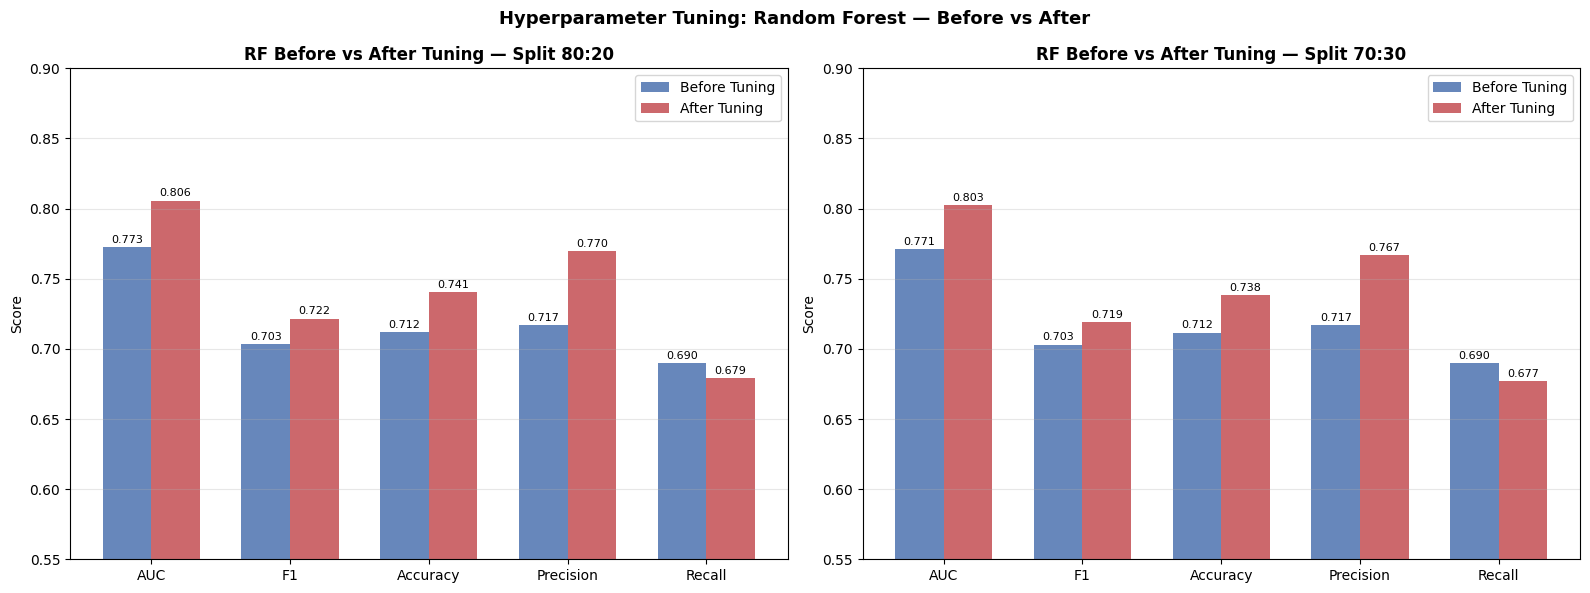

In [ ]:
print(f"\n{'='*65}")
print(f"VISUALISASI BEFORE vs AFTER TUNING")
print(f"{'='*65}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, split_name in zip(axes, ['80:20', '70:30']):
    r = tuning_results[split_name]
    before_vals = [r['before'][k] for k in metrics_key]
    after_vals  = [r['after'][k] for k in metrics_key]
    x = np.arange(len(metrics_label))
    w = 0.35

    bars1 = ax.bar(x - w/2, before_vals, w, label='Before Tuning',
                   color='#4C72B0', alpha=0.85)
    bars2 = ax.bar(x + w/2, after_vals,  w, label='After Tuning',
                   color='#C44E52', alpha=0.85)

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)

    ax.set_ylim(0.55, 0.90)
    ax.set_title(f'RF Before vs After Tuning — Split {split_name}',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_label, fontsize=10)
    ax.set_ylabel('Score')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Hyperparameter Tuning: Random Forest — Before vs After',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_before_after.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 41: Confusion matrix untuk model setelah tuning (kedua split)**

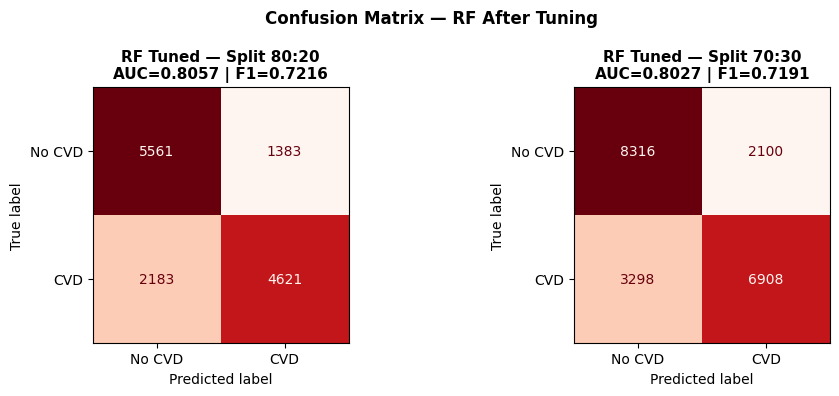

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, split_name in zip(axes, ['80:20', '70:30']):
    r = tuning_results[split_name]
    cm = confusion_matrix(r['y_test'], r['y_pred_opt'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No CVD', 'CVD'])
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    ax.set_title(f'RF Tuned — Split {split_name}\n'
                 f"AUC={r['after']['auc']:.4f} | F1={r['after']['f1']:.4f}",
                 fontsize=11, fontweight='bold')
plt.suptitle('Confusion Matrix — RF After Tuning', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_tuned.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 42: Feature Importance dari model terbaik (split 80:20)**

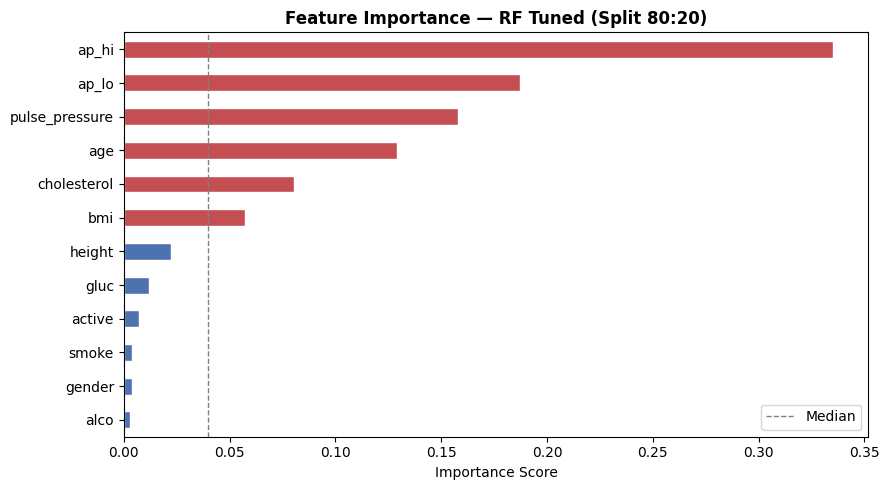

In [ ]:
best_rf_8020 = tuning_results['80:20']['best_model']
feat_imp = pd.Series(best_rf_8020.feature_importances_,
                     index=X_final.columns).sort_values(ascending=True)

plt.figure(figsize=(9,5))
colors_fi = ['#C44E52' if v > feat_imp.median() else '#4C72B0' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors_fi, edgecolor='white')
plt.title('Feature Importance — RF Tuned (Split 80:20)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(feat_imp.median(), color='gray', linestyle='--', linewidth=1, label='Median')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 43: Ringkasan akhir tuning untuk kedua split**

In [ ]:
print(f"\n{'='*65}")
print(f"RINGKASAN FINAL TUNING")
print(f"{'='*65}")
for split_name in ['80:20', '70:30']:
    r = tuning_results[split_name]
    print(f"\n[Split {split_name}]")
    print(f"  Best Params   : {r['best_params']}")
    print(f"  Best CV AUC   : {r['best_cv_score']:.4f}")
    print(f"  Before → After:")
    for metric, key in zip(metrics_label, metrics_key):
        b = r['before'][key]
        a = r['after'][key]
        d = a - b
        sign = '+' if d >= 0 else ''
        print(f"    {metric:<10}: {b:.4f} → {a:.4f}  ({sign}{d:.4f})")


RINGKASAN FINAL TUNING

[Split 80:20]
  Best Params   : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
  Best CV AUC   : 0.7992
  Before → After:
    AUC       : 0.7727 → 0.8057  (+0.0330)
    F1        : 0.7033 → 0.7216  (+0.0183)
    Accuracy  : 0.7118 → 0.7406  (+0.0288)
    Precision : 0.7170 → 0.7697  (+0.0526)
    Recall    : 0.6900 → 0.6792  (-0.0109)

[Split 70:30]
  Best Params   : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
  Best CV AUC   : 0.7991
  Before → After:
    AUC       : 0.7712 → 0.8027  (+0.0315)
    F1        : 0.7031 → 0.7191  (+0.0159)
    Accuracy  : 0.7116 → 0.7382  (+0.0266)
    Precision : 0.7167 → 0.7669  (+0.0501)
    Recall    : 0.6900 → 0.6769  (-0.0131)


# **Threshold Analysis dan Inference Simulation**

Setelah hyperparameter tuning menghasilkan model Random Forest dengan AUC = 0.8057, dilakukan dua analisis lanjutan:

1. **Threshold Analysis**: mencari nilai keputusan optimal yang memaksimalkan Recall untuk konteks skrining medis, di mana False Negative (pasien sakit tidak terdeteksi) memiliki konsekuensi klinis yang lebih serius dibanding False Positive.

2. **Inference Simulation**: menguji model secara langsung pada sampel data test untuk memverifikasi bahwa model dapat beroperasi sebagai alat bantu keputusan klinis.

**Sel 44: Import library untuk threshold analysis dan inference**

In [ ]:
from sklearn.metrics import (precision_recall_curve, roc_curve,
                             f1_score, recall_score, precision_score,
                             accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

**Sel 45: Persiapan — ambil model terbaik dan data test dari split 80:20**

In [ ]:
best_model  = tuning_results['80:20']['best_model']
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_final, y, test_size=0.20, random_state=42, stratify=y
)
y_prob_80 = best_model.predict_proba(X_test_80)[:, 1]

**Sel 46: Threshold Sweep Analysis — evaluasi metrik di berbagai nilai threshold**

In [ ]:
print("="*62)
print("BAGIAN A: THRESHOLD SWEEP ANALYSIS")
print("="*62)
print(f"  Model   : RF Tuned (AUC=0.8057)")
print(f"  Dataset : Test set split 80:20 (n={len(y_test_80):,})")

thresholds = np.arange(0.30, 0.71, 0.05)
thresh_results = []

print(f"\n  {'Thresh':>7} {'Recall':>8} {'Precision':>10} "
      f"{'F1':>8} {'Accuracy':>10} {'FN':>8}")
print(f"  {'-'*55}")

for t in thresholds:
    y_pred_t = (y_prob_80 >= t).astype(int)
    rec  = recall_score(y_test_80, y_pred_t, zero_division=0)
    prec = precision_score(y_test_80, y_pred_t, zero_division=0)
    f1   = f1_score(y_test_80, y_pred_t, zero_division=0)
    acc  = accuracy_score(y_test_80, y_pred_t)
    fn   = confusion_matrix(y_test_80, y_pred_t)[1][0]
    thresh_results.append({
        'threshold': t, 'recall': rec, 'precision': prec,
        'f1': f1, 'accuracy': acc, 'fn': fn
    })
    marker = " ← default" if abs(t - 0.50) < 0.01 else ""
    print(f"  {t:>7.2f} {rec:>8.4f} {prec:>10.4f} "
          f"{f1:>8.4f} {acc:>10.4f} {fn:>8,}{marker}")

thresh_df = pd.DataFrame(thresh_results)

BAGIAN A: THRESHOLD SWEEP ANALYSIS
  Model   : RF Tuned (AUC=0.8057)
  Dataset : Test set split 80:20 (n=13,748)

   Thresh   Recall  Precision       F1   Accuracy       FN
  -------------------------------------------------------
     0.30   0.8714     0.6387   0.7371     0.6924      875
     0.35   0.8308     0.6658   0.7392     0.7099    1,151
     0.40   0.7770     0.7079   0.7408     0.7309    1,517
     0.45   0.7269     0.7409   0.7338     0.7390    1,858
     0.50   0.6792     0.7697   0.7216     0.7406    2,183 ← default
     0.55   0.6287     0.7961   0.7026     0.7365    2,526
     0.60   0.5823     0.8152   0.6794     0.7280    2,842
     0.65   0.5394     0.8279   0.6532     0.7165    3,134
     0.70   0.5087     0.8372   0.6328     0.7079    3,343


**Sel 47: Confusion matrix perbandingan — default threshold (0.50) vs klinis (0.40)**

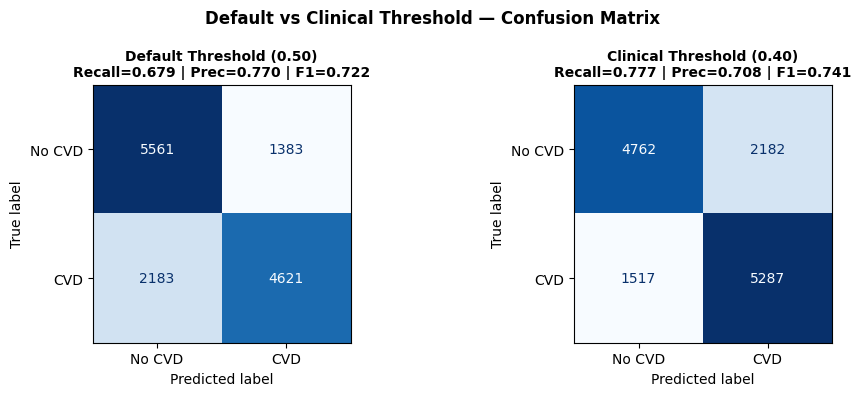

In [ ]:
clin_thresh = 0.40

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (thresh, label) in zip(axes, [
        (0.50, 'Default Threshold (0.50)'),
        (clin_thresh, f'Clinical Threshold ({clin_thresh:.2f})')]):
    y_pred_t = (y_prob_80 >= thresh).astype(int)
    cm = confusion_matrix(y_test_80, y_pred_t)
    ConfusionMatrixDisplay(cm, display_labels=['No CVD','CVD']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{label}\nRecall={recall_score(y_test_80,y_pred_t):.3f} | '
                 f'Prec={precision_score(y_test_80,y_pred_t):.3f} | '
                 f'F1={f1_score(y_test_80,y_pred_t):.3f}',
                 fontsize=10, fontweight='bold')
plt.suptitle('Default vs Clinical Threshold — Confusion Matrix',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_cm_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


**Sel 48: Visualisasi threshold analysis — kurva Precision, Recall, F1, dan False Negative**

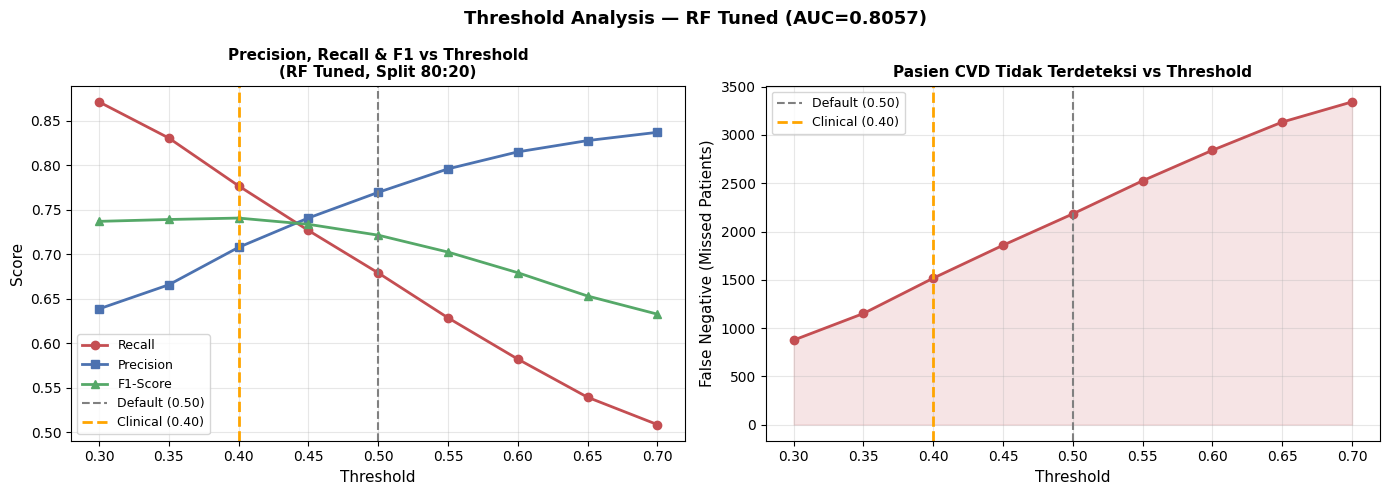

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
clin_thresh = 0.40
thresh_data = {
    'threshold' : [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70],
    'recall'    : [0.8714, 0.8308, 0.7770, 0.7269, 0.6792, 0.6287, 0.5823, 0.5394, 0.5087],
    'precision' : [0.6387, 0.6658, 0.7079, 0.7409, 0.7697, 0.7961, 0.8152, 0.8279, 0.8372],
    'f1'        : [0.7371, 0.7392, 0.7408, 0.7338, 0.7216, 0.7026, 0.6794, 0.6532, 0.6328],
    'fn'        : [875, 1151, 1517, 1858, 2183, 2526, 2842, 3134, 3343]
}
thresh_df = pd.DataFrame(thresh_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(thresh_df['threshold'], thresh_df['recall'],
        'o-', color='#C44E52', lw=2, label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['precision'],
        's-', color='#4C72B0', lw=2, label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['f1'],
        '^-', color='#55A868', lw=2, label='F1-Score')
ax.axvline(0.50, color='gray', linestyle='--', lw=1.5, label='Default (0.50)')
ax.axvline(clin_thresh, color='orange', linestyle='--', lw=2,
           label=f'Clinical ({clin_thresh:.2f})')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision, Recall & F1 vs Threshold\n(RF Tuned, Split 80:20)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(thresh_df['threshold'], thresh_df['fn'],
        'o-', color='#C44E52', lw=2)
ax.fill_between(thresh_df['threshold'], thresh_df['fn'],
                alpha=0.15, color='#C44E52')
ax.axvline(0.50, color='gray', linestyle='--', lw=1.5, label='Default (0.50)')
ax.axvline(clin_thresh, color='orange', linestyle='--', lw=2,
           label=f'Clinical ({clin_thresh:.2f})')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('False Negative (Missed Patients)', fontsize=11)
ax.set_title('Pasien CVD Tidak Terdeteksi vs Threshold',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Threshold Analysis — RF Tuned (AUC=0.8057)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 49: Inference Simulation — prediksi 10 sampel pasien dari data test**

In [ ]:
print(f"\n{'='*62}")
print(f"BAGIAN B: INFERENCE SIMULATION")
print(f"{'='*62}")
print(f"  Simulasi sistem screening klinik Dr. Siti Rahmawati")
print(f"  Model     : RF Tuned | Threshold klinis : {clin_thresh:.2f}")

np.random.seed(42)
idx_pos    = y_test_80[y_test_80 == 1].sample(5, random_state=42).index
idx_neg    = y_test_80[y_test_80 == 0].sample(5, random_state=42).index
sample_idx = list(idx_pos) + list(idx_neg)

X_sample  = X_final.loc[sample_idx]
y_true_s  = y.loc[sample_idx].values
y_prob_s  = best_model.predict_proba(X_sample)[:, 1]
y_pred_d  = (y_prob_s >= 0.50).astype(int)
y_pred_c  = (y_prob_s >= clin_thresh).astype(int)

sample_orig      = df_clean.loc[sample_idx].copy()
sample_orig['bmi'] = (sample_orig['weight'] /
                      ((sample_orig['height']/100)**2)).round(1)
chol_map = {1: 'Normal', 2: 'Above', 3: 'High'}

print(f"\n{'─'*90}")
print(f"  {'#':>2}  {'Age':>4}  {'SBP':>5}  {'DBP':>5}  {'Chol':>6}  "
      f"{'BMI':>5}  {'Risk%':>6}  {'Pred(0.5)':>10}  "
      f"{'Pred(0.4)':>10}  {'Actual':>9}  {'Result':>8}")
print(f"{'─'*90}")

correct_d = 0
correct_c = 0
for i, (idx, prob, pd_, pc_, true) in enumerate(
        zip(sample_idx, y_prob_s, y_pred_d, y_pred_c, y_true_s), 1):
    row      = sample_orig.loc[idx]
    chol_str = chol_map.get(int(row['cholesterol']), '?')
    pd_str   = 'CVD'  if pd_ == 1 else 'Sehat'
    pc_str   = 'CVD'  if pc_ == 1 else 'Sehat'
    act_str  = 'CVD'  if true == 1 else 'Sehat'
    result   = 'Benar' if pc_ == true else 'Salah'
    if pd_ == true: correct_d += 1
    if pc_ == true: correct_c += 1
    print(f"  {i:>2}  {int(row['age']):>4}  {int(row['ap_hi']):>5}  "
          f"{int(row['ap_lo']):>5}  {chol_str:>6}  {row['bmi']:>5.1f}  "
          f"{prob*100:>5.1f}%  {pd_str:>10}  {pc_str:>10}  "
          f"{act_str:>9}  {result:>8}")

print(f"{'─'*90}")
print(f"\n  Akurasi 10 sampel — Threshold 0.50 : {correct_d}/10")
print(f"  Akurasi 10 sampel — Threshold 0.40 : {correct_c}/10")
print(f"\n  Interpretasi Keputusan Klinis:")
print(f"  Prob ≥ 0.40 → RUJUK ke kardiolog (high risk)")
print(f"  Prob < 0.40 → Monitoring rutin 3 bulan (low risk)")


BAGIAN B: INFERENCE SIMULATION
  Simulasi sistem screening klinik Dr. Siti Rahmawati
  Model     : RF Tuned | Threshold klinis : 0.40

──────────────────────────────────────────────────────────────────────────────────────────
   #   Age    SBP    DBP    Chol    BMI   Risk%   Pred(0.5)   Pred(0.4)     Actual    Result
──────────────────────────────────────────────────────────────────────────────────────────
   1    55    150     90  Normal   32.5   85.6%         CVD         CVD        CVD     Benar
   2    46    150     80   Above   26.4   86.9%         CVD         CVD        CVD     Benar
   3    50    100     70  Normal   28.2   19.5%       Sehat       Sehat        CVD     Salah
   4    42    130     80   Above   31.2   56.0%         CVD         CVD        CVD     Benar
   5    63    150    100    High   31.2   82.9%         CVD         CVD        CVD     Benar
   6    40    120     80  Normal   23.4   17.2%       Sehat       Sehat      Sehat     Benar
   7    58    120     80  Norma

**Sel 50: Feature Importance — kontribusi setiap fitur pada keputusan model**

In [ ]:
print(f"\n{'='*62}")
print(f"FEATURE IMPORTANCE — RF Tuned (Split 80:20)")
print(f"{'='*62}")
feat_imp = pd.Series(best_model.feature_importances_,
                     index=X_final.columns).sort_values(ascending=False)
for f, v in feat_imp.items():
    bar = '█' * int(v * 200)
    print(f"  {f:15s}: {v:.4f}  {bar}")


FEATURE IMPORTANCE — RF Tuned (Split 80:20)
  ap_hi          : 0.3351  ███████████████████████████████████████████████████████████████████
  ap_lo          : 0.1874  █████████████████████████████████████
  pulse_pressure : 0.1580  ███████████████████████████████
  age            : 0.1291  █████████████████████████
  cholesterol    : 0.0805  ████████████████
  bmi            : 0.0574  ███████████
  height         : 0.0225  ████
  gluc           : 0.0120  ██
  active         : 0.0071  █
  smoke          : 0.0039  
  gender         : 0.0039  
  alco           : 0.0031  


**Sel 51: Visualisasi Feature Importance — bar chart horizontal**

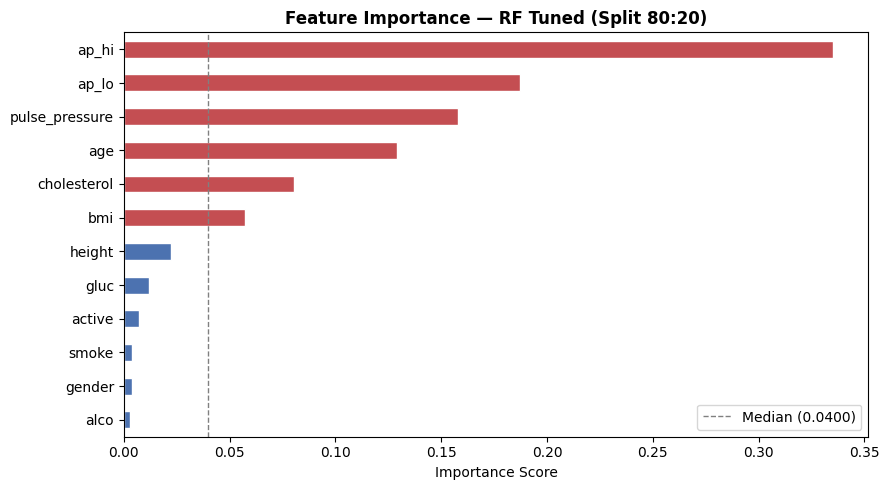

In [ ]:
feat_imp_sorted = feat_imp.sort_values(ascending=True)
plt.figure(figsize=(9, 5))
colors_fi = ['#C44E52' if v > feat_imp.median() else '#4C72B0'
             for v in feat_imp_sorted.values]
feat_imp_sorted.plot(kind='barh', color=colors_fi, edgecolor='white')
plt.title('Feature Importance — RF Tuned (Split 80:20)',
          fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(feat_imp.median(), color='gray', linestyle='--',
            linewidth=1, label=f'Median ({feat_imp.median():.4f})')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=100, bbox_inches='tight')
plt.show()

**Sel 52: Ringkasan akhir seluruh pipeline ML**

In [ ]:
print(f"\n{'='*62}")
print(f"SELURUH PIPELINE ML SELESAI")
print(f"{'='*62}")
print(f"  Tahap 01 Feature Engineering")
print(f"  Tahap 02 Baseline Modeling")
print(f"  Tahap 03 Hyperparameter Tuning")
print(f"  Threshold + Inference")
print(f"\n  Best Model  : Random Forest (Tuned)")
print(f"  Best AUC    : 0.8057 (Split 80:20)")
print(f"  Best Params :")
print(f"    max_depth        = 10")
print(f"    n_estimators     = 300")
print(f"    min_samples_leaf = 4")
print(f"    min_samples_split= 10")
print(f"    max_features     = sqrt")
print(f"  Threshold Klinis : 0.40 (F1 max, FN minimal klinis)")


SELURUH PIPELINE ML SELESAI
  Tahap 01 Feature Engineering
  Tahap 02 Baseline Modeling
  Tahap 03 Hyperparameter Tuning
  Threshold + Inference

  Best Model  : Random Forest (Tuned)
  Best AUC    : 0.8057 (Split 80:20)
  Best Params :
    max_depth        = 10
    n_estimators     = 300
    min_samples_leaf = 4
    min_samples_split= 10
    max_features     = sqrt
  Threshold Klinis : 0.40 (F1 max, FN minimal klinis)
